In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

In [ ]:

# Import MDSS (Assuming library is installed/available)
from mdss.MDSS import MDSS
from mdss.ScoringFunctions.Bernoulli import Bernoulli

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
print("--- 1. Loading & Preprocessing ---")

# Load Data
tax_df = pd.read_excel('/Users/kayadetunji/Documents/DM_work/raw data_taxonomy_CFC.xlsx', sheet_name='taxonomy')
chem_df = pd.read_excel('/Users/kayadetunji/Documents/DM_work/raw data_taxonomy_CFC.xlsx', sheet_name='properties')

# Define Groups
gz_cols = ['GZ1', 'GZ2', 'GZ3', 'GZ4']
ag_cols = ['AG1', 'AG2', 'AG3', 'AG4']
all_samples = gz_cols + ag_cols

# Filter Rare Taxa (Prevalence > 3 samples) - Crucial for Network Stability
counts = tax_df[all_samples]
mask = (counts > 0).sum(axis=1) >= 3
df_clean = tax_df[mask].reset_index(drop=True)
print(f"Taxa retained for Network Analysis: {len(df_clean)}")

# CLR Transformation (Centered Log-Ratio) - The STORMS Standard
# Log-transform counts relative to the geometric mean per sample
def clr_transform(count_df):
    # Add pseudo-count to handle zeros
    df_log = np.log(count_df + 1)
    # Subtract geometric mean (mean of logs)
    geometric_mean = df_log.mean(axis=0) # centered on sample
    return df_log.sub(geometric_mean, axis=1)

df_clr = clr_transform(df_clean[all_samples])
# Transpose for Correlation (Rows=Samples, Cols=Taxa)
X = df_clr.T 

# ==========================================
# 2. ROBUST NETWORK CONSTRUCTION (Bootstrapping)
# ==========================================
print("\n--- 2. Constructing Robust Network (Bootstrapped) ---")
# Problem: N=12 is small. 
# Solution: Run 100 bootstraps. Only keep edges that appear in >70% of runs.

n_boot = 50  # Use 50-100 for speed (increase for final paper)
threshold_rho = 0.7 # Strong correlation only
consensus_matrix = np.zeros((X.shape[1], X.shape[1]))

print(f"Running {n_boot} bootstrap iterations...")
for i in range(n_boot):
    # Resample samples with replacement
    X_resampled = resample(X)
    
    # Calculate Spearman Correlation
    corr, _ = spearmanr(X_resampled)
    # Handle NaNs if any variance is 0
    corr = np.nan_to_num(corr)
    
    # Binarize: 1 if correlation is strong, 0 otherwise
    # adj = (np.abs(corr) >= threshold_rho).astype(int)
    adj = (corr >= threshold_rho).astype(int)   # positive only
    consensus_matrix += adj

# Normalize consensus (0.0 to 1.0 probability of edge)
consensus_matrix = consensus_matrix / n_boot

# Final Adjacency: Keep edges present in >70% of bootstraps
final_adjacency = (consensus_matrix >= 0.7).astype(int)
np.fill_diagonal(final_adjacency, 0) # Self-correlation is 1

print(f"Network Constructed. Density: {np.mean(final_adjacency):.3f}")


--- 1. Loading & Preprocessing ---
Taxa retained for Network Analysis: 298

--- 2. Constructing Robust Network (Bootstrapped) ---
Running 50 bootstrap iterations...
Network Constructed. Density: 0.019



--- 3. Detecting Ecological Modules ---


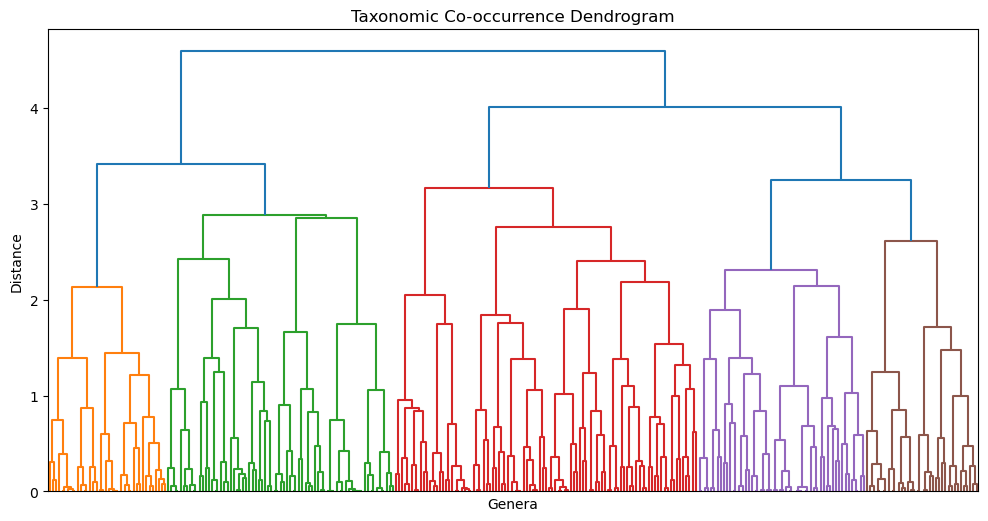

Identified 4 distinct Co-abundance Modules.

--- 4. Module Annotation ---


,Module,Size,Dominant_Phylum,Representative_Genera
0,M1,38,Proteobacteria,"[Acidithiomicrobium, Aeromicrobium, Agrococcus]"
1,M2,73,Proteobacteria,"[Acidimicrobium, Actinoplanes, Actinotalea]"
2,M3,97,Actinobacteria,"[Acidobacterium, Acidothermus, Actinoallomurus]"
3,M4,90,Actinobacteria,"[Acetobacter, Acholeplasma, Acidiphilium]"



--- 5. Calculating Module Eigengenes ---
     Module_1  Module_2  Module_3  Module_4    pH  Nitrate  Zone
GZ1 -2.164525  2.040481 -2.524650 -1.579543  6.79    16.56     0
GZ2 -1.990347 -0.595543 -3.115803 -1.675767  7.04    16.42     0
GZ3  3.206797 -5.270472 -4.369833  6.862992  6.64    18.02     0
GZ4 -2.867772 -6.680669 -6.895536  0.495288  6.45    14.16     0
AG1 -6.065647 -4.400526  4.108506  7.341630  5.49     0.97     1

--- 6. MDSS Interaction Scan ---

MDSS Score: 1.7726
Top Interaction Rule predicting Soil Degradation:
{'Module_3_High': [1]}

--- INTERPRETATION HELP ---
1. Look at 'Module Annotation': Which module contains the N-fixers (Azospirillum)?
2. Look at 'MDSS Rule': Did the scanner pick that specific module?
   Example: If Rule is {'Module_2_Low': [1], 'pH_Low': [1]}, it means
   'When Module 2 collapses AND pH is low, the soil is Degraded.'


In [30]:


# ==========================================
# 3. MODULE DETECTION (Hierarchical Clustering)
# ==========================================
print("\n--- 3. Detecting Ecological Modules ---")
# Convert Consensus Matrix to Distance (1 - Consensus)
# Taxa that are often correlated have distance close to 0
dist_matrix = 1 - consensus_matrix
dist_array = squareform(dist_matrix, checks=False)

# Hierarchical Clustering (Ward's Method)
Z = linkage(dist_array, method='ward')
# Z = linkage(squareform(dist_matrix, checks=False), method='complete')

# Plot Dendrogram (Visual Check)
plt.figure(figsize=(12, 6))
dendrogram(Z, no_labels=True, color_threshold=0.7*max(Z[:,2]))
plt.title("Taxonomic Co-occurrence Dendrogram")
plt.xlabel("Genera")
plt.ylabel("Distance")
plt.show()

# Cut Tree to define Modules
# Adjust 't' (distance threshold) to get 5-10 modules
# cluster_labels = fcluster(Z, t=4, criterion='maxclust') 
# df_clean['Module_ID'] = cluster_labels

# Cut into 4 modules
cluster_labels = fcluster(Z, 4, criterion='maxclust')
df_clean['Module_ID'] = cluster_labels
n_modules = len(np.unique(cluster_labels))
print(f"Identified {n_modules} distinct Co-abundance Modules.")

# ==========================================
# 4. ANNOTATE MODULES (Who is in them?)
# ==========================================
print("\n--- 4. Module Annotation ---")

module_stats = []
for mod_id in np.sort(np.unique(cluster_labels)):
    members = df_clean[df_clean['Module_ID'] == mod_id]
    size = len(members)
    
    # Dominant Phylum
    top_phylum = members['phylum'].mode()[0] if not members['phylum'].mode().empty else "Mix"
    
    # Top 3 Genera names
    top_genera = members['genus'].head(3).tolist()
    
    module_stats.append({
        'Module': f"M{mod_id}",
        'Size': size,
        'Dominant_Phylum': top_phylum,
        'Representative_Genera': top_genera
    })

df_modules = pd.DataFrame(module_stats)
display(df_modules)

# ==========================================
# 5. CALCULATE EIGENGENES (Module Scores)
# ==========================================
print("\n--- 5. Calculating Module Eigengenes ---")

# Eigengene = PC1 of the CLR data for that module
eigengenes = pd.DataFrame(index=all_samples)

pca = PCA(n_components=1)
for mod_id in np.unique(cluster_labels):
    # Get CLR data for just this module
    mod_indices = df_clean.index[df_clean['Module_ID'] == mod_id]
    mod_data = df_clr.iloc[mod_indices].T # Samples x Taxa
    
    # Run PCA
    pc1 = pca.fit_transform(StandardScaler().fit_transform(mod_data))
    
    # Store Score (PC1)
    eigengenes[f"Module_{mod_id}"] = pc1.flatten()

# Add Metadata (Zone, pH, Nitrate)
# We need to extract pH/Nitrate from chem_df and align
chem_t = chem_df.set_index('Variable').T
eigengenes['pH'] = chem_t.loc[all_samples, 'pH'].astype(float)
eigengenes['Nitrate'] = chem_t.loc[all_samples, 'N–NO3(mg/kg)'].astype(float)
eigengenes['Zone'] = [1 if 'AG' in x else 0 for x in all_samples] # 1=Degraded, 0=Healthy

print(eigengenes.head())

# ==========================================
# 6. MDSS RULE MINING (The Interaction Check)
# ==========================================
print("\n--- 6. MDSS Interaction Scan ---")
# We scan Eigengenes + Chemistry to predict Zone (Degraded)

# Features: Module Scores + pH/Nitrate
features = eigengenes.drop(columns=['Zone'])

# Binarize Features for MDSS (High vs Low)
# This creates columns like "Module_1_High", "pH_Low"
features_bin = pd.DataFrame()
for col in features.columns:
    median_val = features[col].median()
    features_bin[f"{col}_High"] = (features[col] > median_val).astype(int)
    features_bin[f"{col}_Low"] = (features[col] <= median_val).astype(int)

# Outcome: Is it Agricultural Soil?
outcome = eigengenes['Zone']
# Expectation: Baseline probability (0.5 for balanced dataset)
expectation = pd.Series([0.5]*len(outcome), index=outcome.index)

# Setup MDSS Scanner (Bernoulli because Outcome is Binary Class)
scoring_function = Bernoulli(direction='positive') # Look for rule that predicts Class=1 (AG)
scanner = MDSS(scoring_function)

# Run Scan
subset, score = scanner.scan(
    coordinates=features_bin,
    outcomes=outcome,
    expectations=expectation,
    penalty=1.0,
    num_iters=10,
    mode='binary',
    verbose=False
)

print(f"\nMDSS Score: {score:.4f}")
print("Top Interaction Rule predicting Soil Degradation:")
print(subset)

# Interpretation Logic
print("\n--- INTERPRETATION HELP ---")
print("1. Look at 'Module Annotation': Which module contains the N-fixers (Azospirillum)?")
print("2. Look at 'MDSS Rule': Did the scanner pick that specific module?")
print("   Example: If Rule is {'Module_2_Low': [1], 'pH_Low': [1]}, it means")
print("   'When Module 2 collapses AND pH is low, the soil is Degraded.'")

Generating Figure 1: Network Topology...


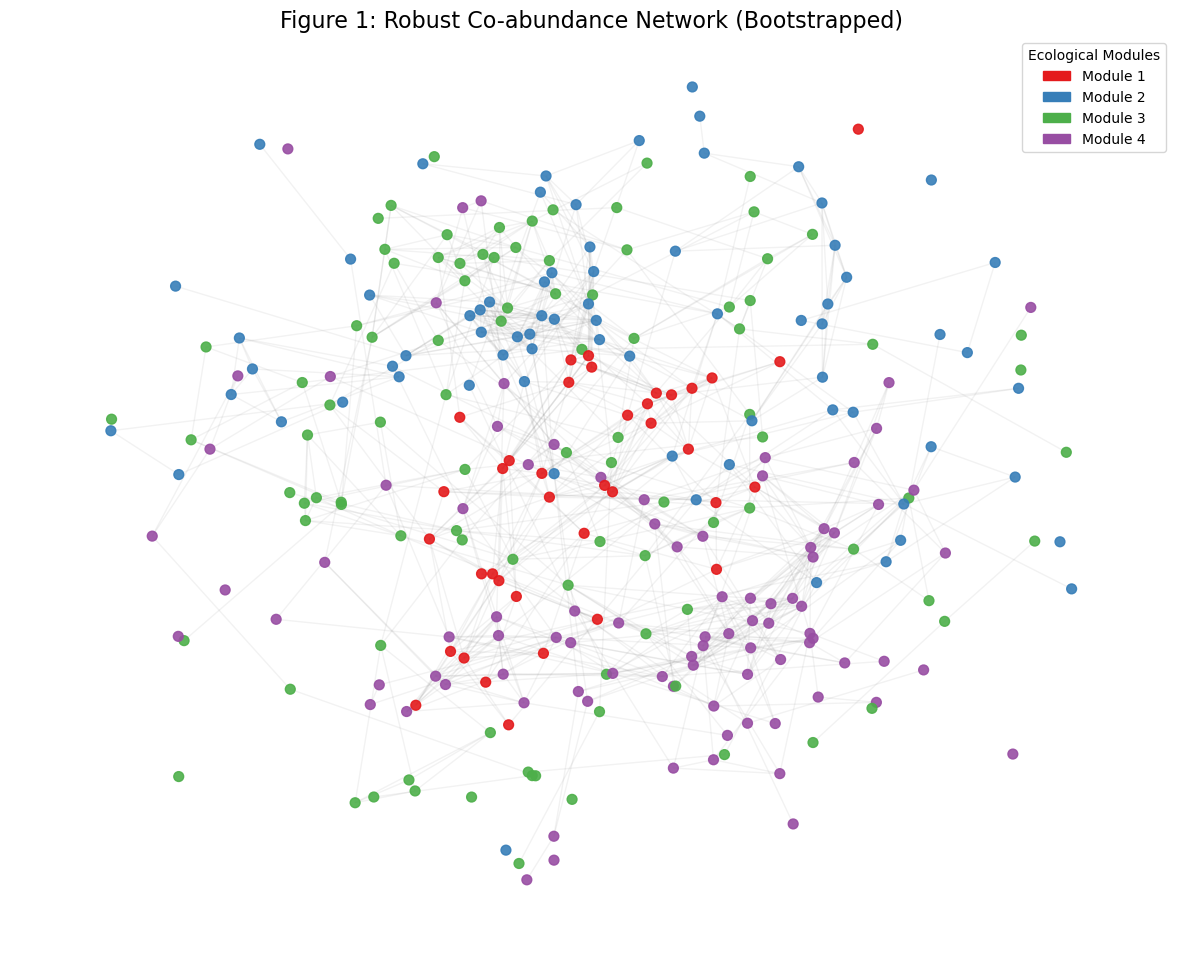

Generating Figure 2: Module Composition...


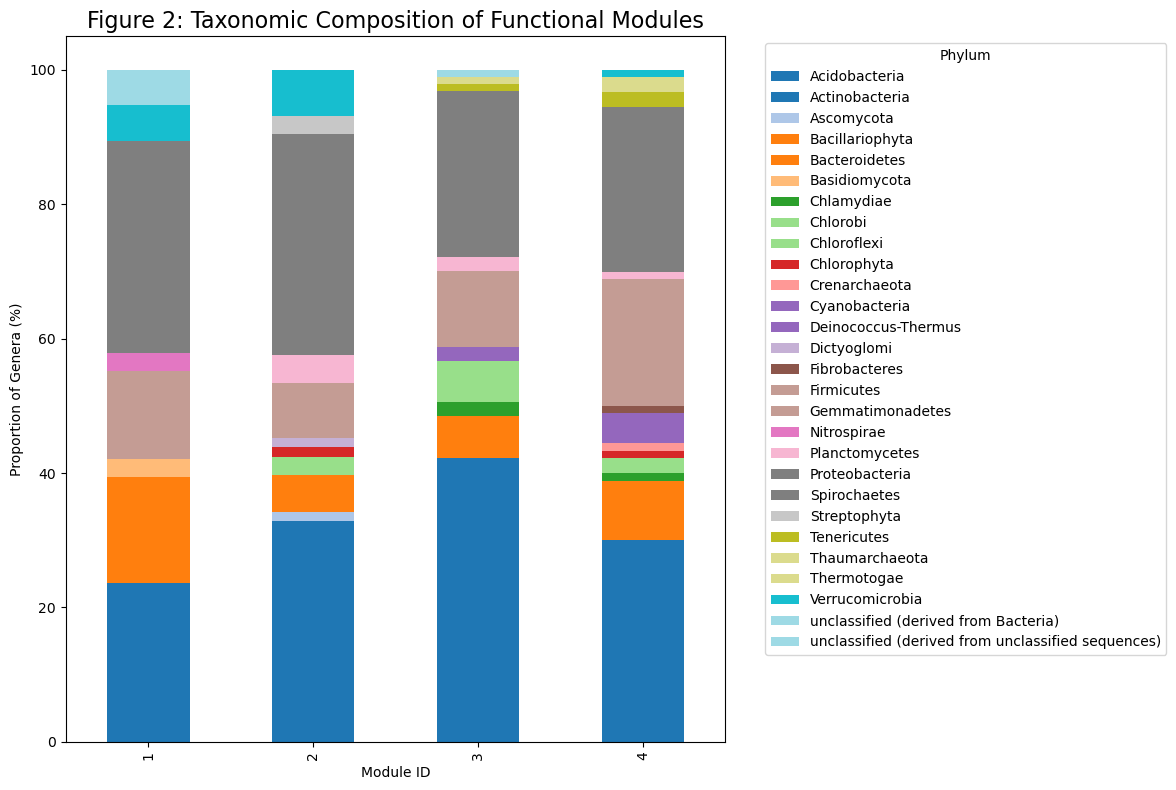

Generating Figure 3: Eigengene Response...


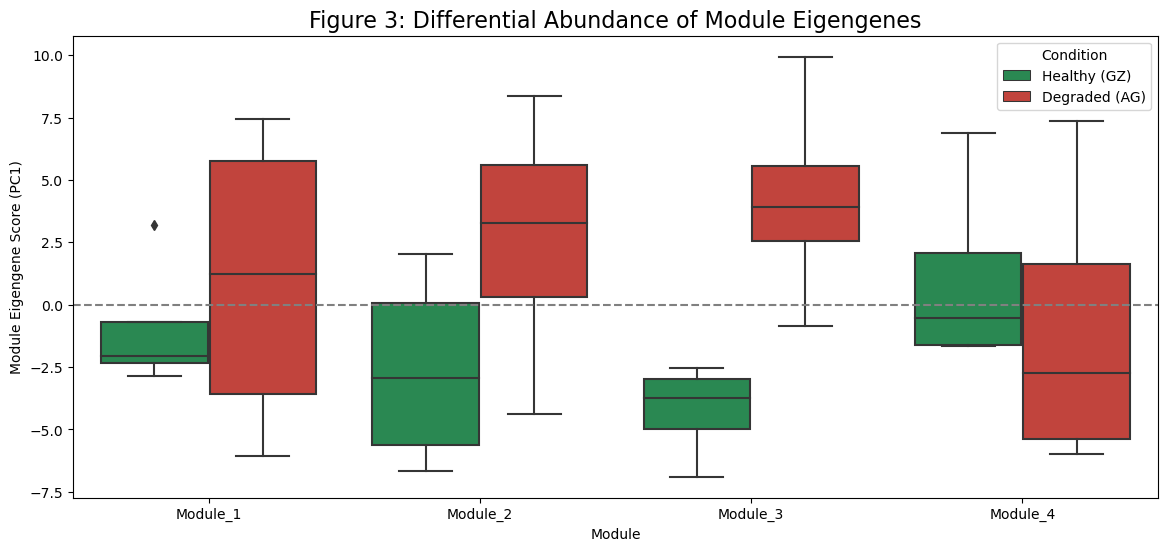

In [31]:
import networkx as nx
import matplotlib.patches as mpatches

# ==========================================
# FIGURE 1: THE NETWORK TOPOLOGY PLOT
# ==========================================
# We use the 'final_adjacency' matrix (edges > 70% bootstrap support)

print("Generating Figure 1: Network Topology...")
plt.figure(figsize=(15, 12))

# 1. Create Graph Object
G = nx.from_numpy_array(final_adjacency)

# 2. Map Node Attributes (Module Color)
# We need a color map for M1, M2, M3, M4
module_map = df_clean['Module_ID'].to_dict()
# Colors: M1=Red, M2=Blue, M3=Green, M4=Purple
color_palette = {1: '#e41a1c', 2: '#377eb8', 3: '#4daf4a', 4: '#984ea3'}
node_colors = [color_palette.get(module_map.get(i), 'grey') for i in G.nodes()]

# 3. Layout (Fruchterman-Reingold is standard for force-directed)
pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42)

# 4. Draw
# Draw edges (light grey)
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='grey')
# Draw nodes (colored by module)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=50, alpha=0.9)

# 5. Legend
legend_handles = [mpatches.Patch(color=color, label=f"Module {m}") for m, color in color_palette.items()]
plt.legend(handles=legend_handles, title="Ecological Modules", loc='upper right')
plt.title("Figure 1: Robust Co-abundance Network (Bootstrapped)", fontsize=16)
plt.axis('off')
plt.show()

# ==========================================
# FIGURE 2: MODULE COMPOSITION (Stacked Bar)
# ==========================================
# "Who is in these modules?"

print("Generating Figure 2: Module Composition...")
# Crosstab Module vs Phylum
mod_comp = pd.crosstab(df_clean['Module_ID'], df_clean['phylum'])
# Normalize to percentages
mod_comp_pct = mod_comp.div(mod_comp.sum(axis=1), axis=0) * 100

# Plot
ax = mod_comp_pct.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')
plt.title("Figure 2: Taxonomic Composition of Functional Modules", fontsize=16)
plt.xlabel("Module ID")
plt.ylabel("Proportion of Genera (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Phylum')
plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 3: MODULE RESPONSE (Box Plots)
# ==========================================
# "How do these modules behave in AG vs GZ?"

print("Generating Figure 3: Eigengene Response...")
# Prepare data: Melt the eigengenes dataframe for plotting
# Columns currently: Module_1, Module_2..., Zone
plot_data = eigengenes.melt(id_vars=['Zone'], 
                            value_vars=[c for c in eigengenes.columns if 'Module' in c],
                            var_name='Module', value_name='Eigengene_Score')

# Map Zone 0/1 to Labels
plot_data['Condition'] = plot_data['Zone'].map({0: 'Healthy (GZ)', 1: 'Degraded (AG)'})

plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_data, x='Module', y='Eigengene_Score', hue='Condition', 
            palette={'Healthy (GZ)': '#1a9850', 'Degraded (AG)': '#d73027'})
plt.title("Figure 3: Differential Abundance of Module Eigengenes", fontsize=16)
plt.ylabel("Module Eigengene Score (PC1)")
plt.axhline(0, linestyle='--', color='grey')
plt.show()

In [22]:
print("\n--- 6b. MDSS Biological Scan (Modules Only) ---")

# Drop the chemical columns from the search space
bio_features = eigengenes.drop(columns=['Zone', 'pH', 'Nitrate'])

# Binarize
bio_features_bin = pd.DataFrame()
for col in bio_features.columns:
    median_val = bio_features[col].median()
    bio_features_bin[f"{col}_High"] = (bio_features[col] > median_val).astype(int)
    bio_features_bin[f"{col}_Low"] = (bio_features[col] <= median_val).astype(int)

# Run Scan Again
subset_bio, score_bio = scanner.scan(
    coordinates=bio_features_bin,
    outcomes=outcome,
    expectations=expectation,
    penalty=0.4,
    num_iters=10,
    # mode='binary',
    # verbose=False
)

print("Top BIOLOGICAL Rule predicting Degradation:")
print(subset_bio)


--- 6b. MDSS Biological Scan (Modules Only) ---
Top BIOLOGICAL Rule predicting Degradation:
{'Module_4_Low': [0]}


Taxa after prevalence + genus collapse: 352
Taxa after top-variance cap: 50


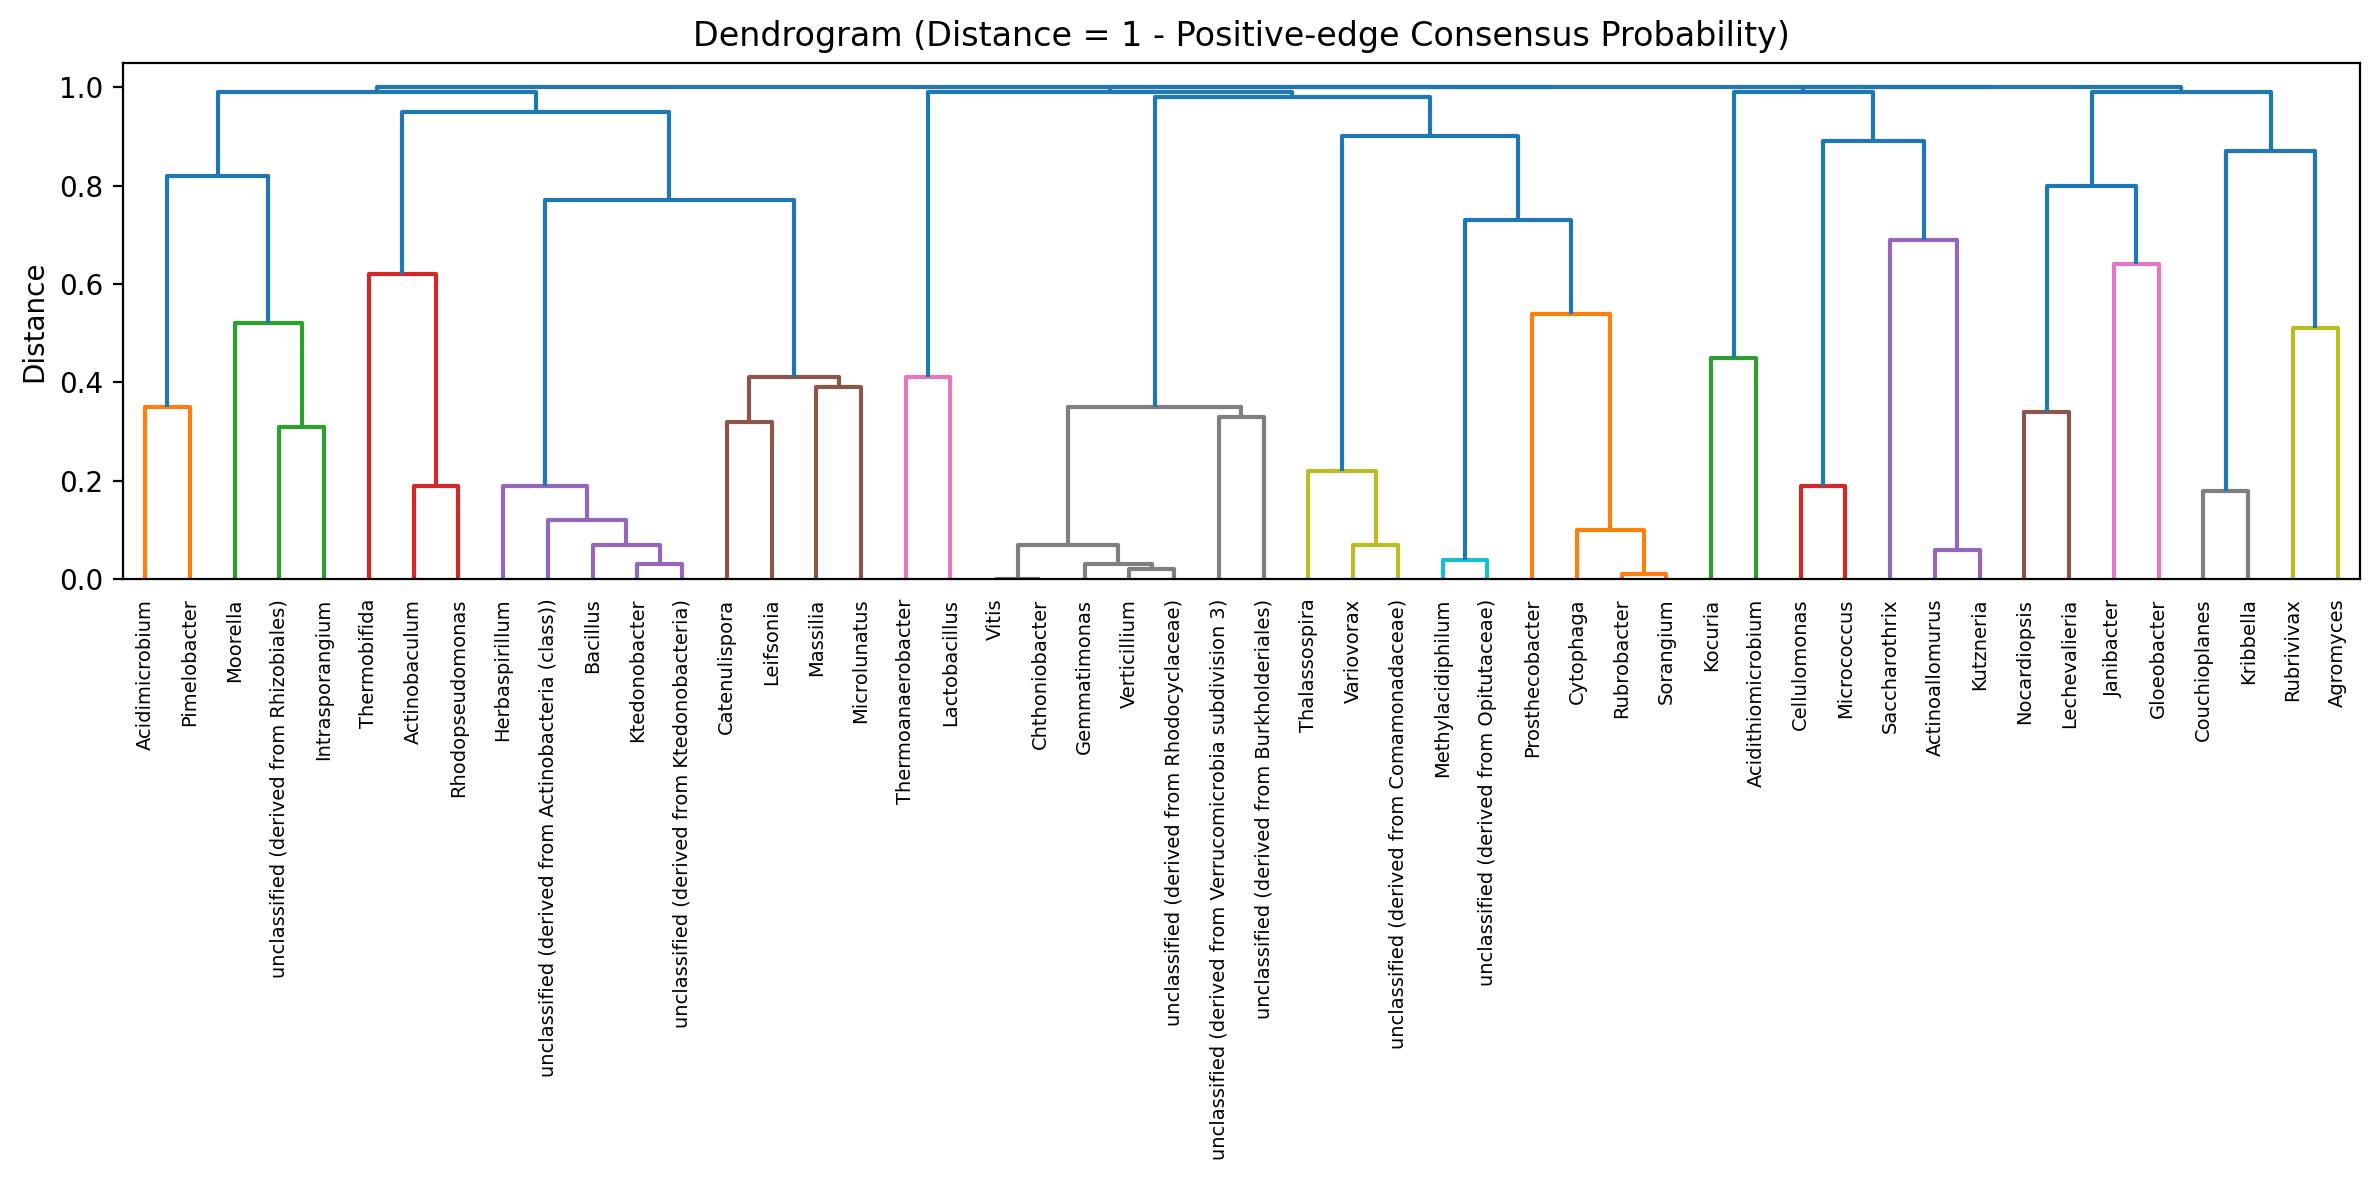

Edges kept: 143 out of 1225 => density 0.11673469387755102


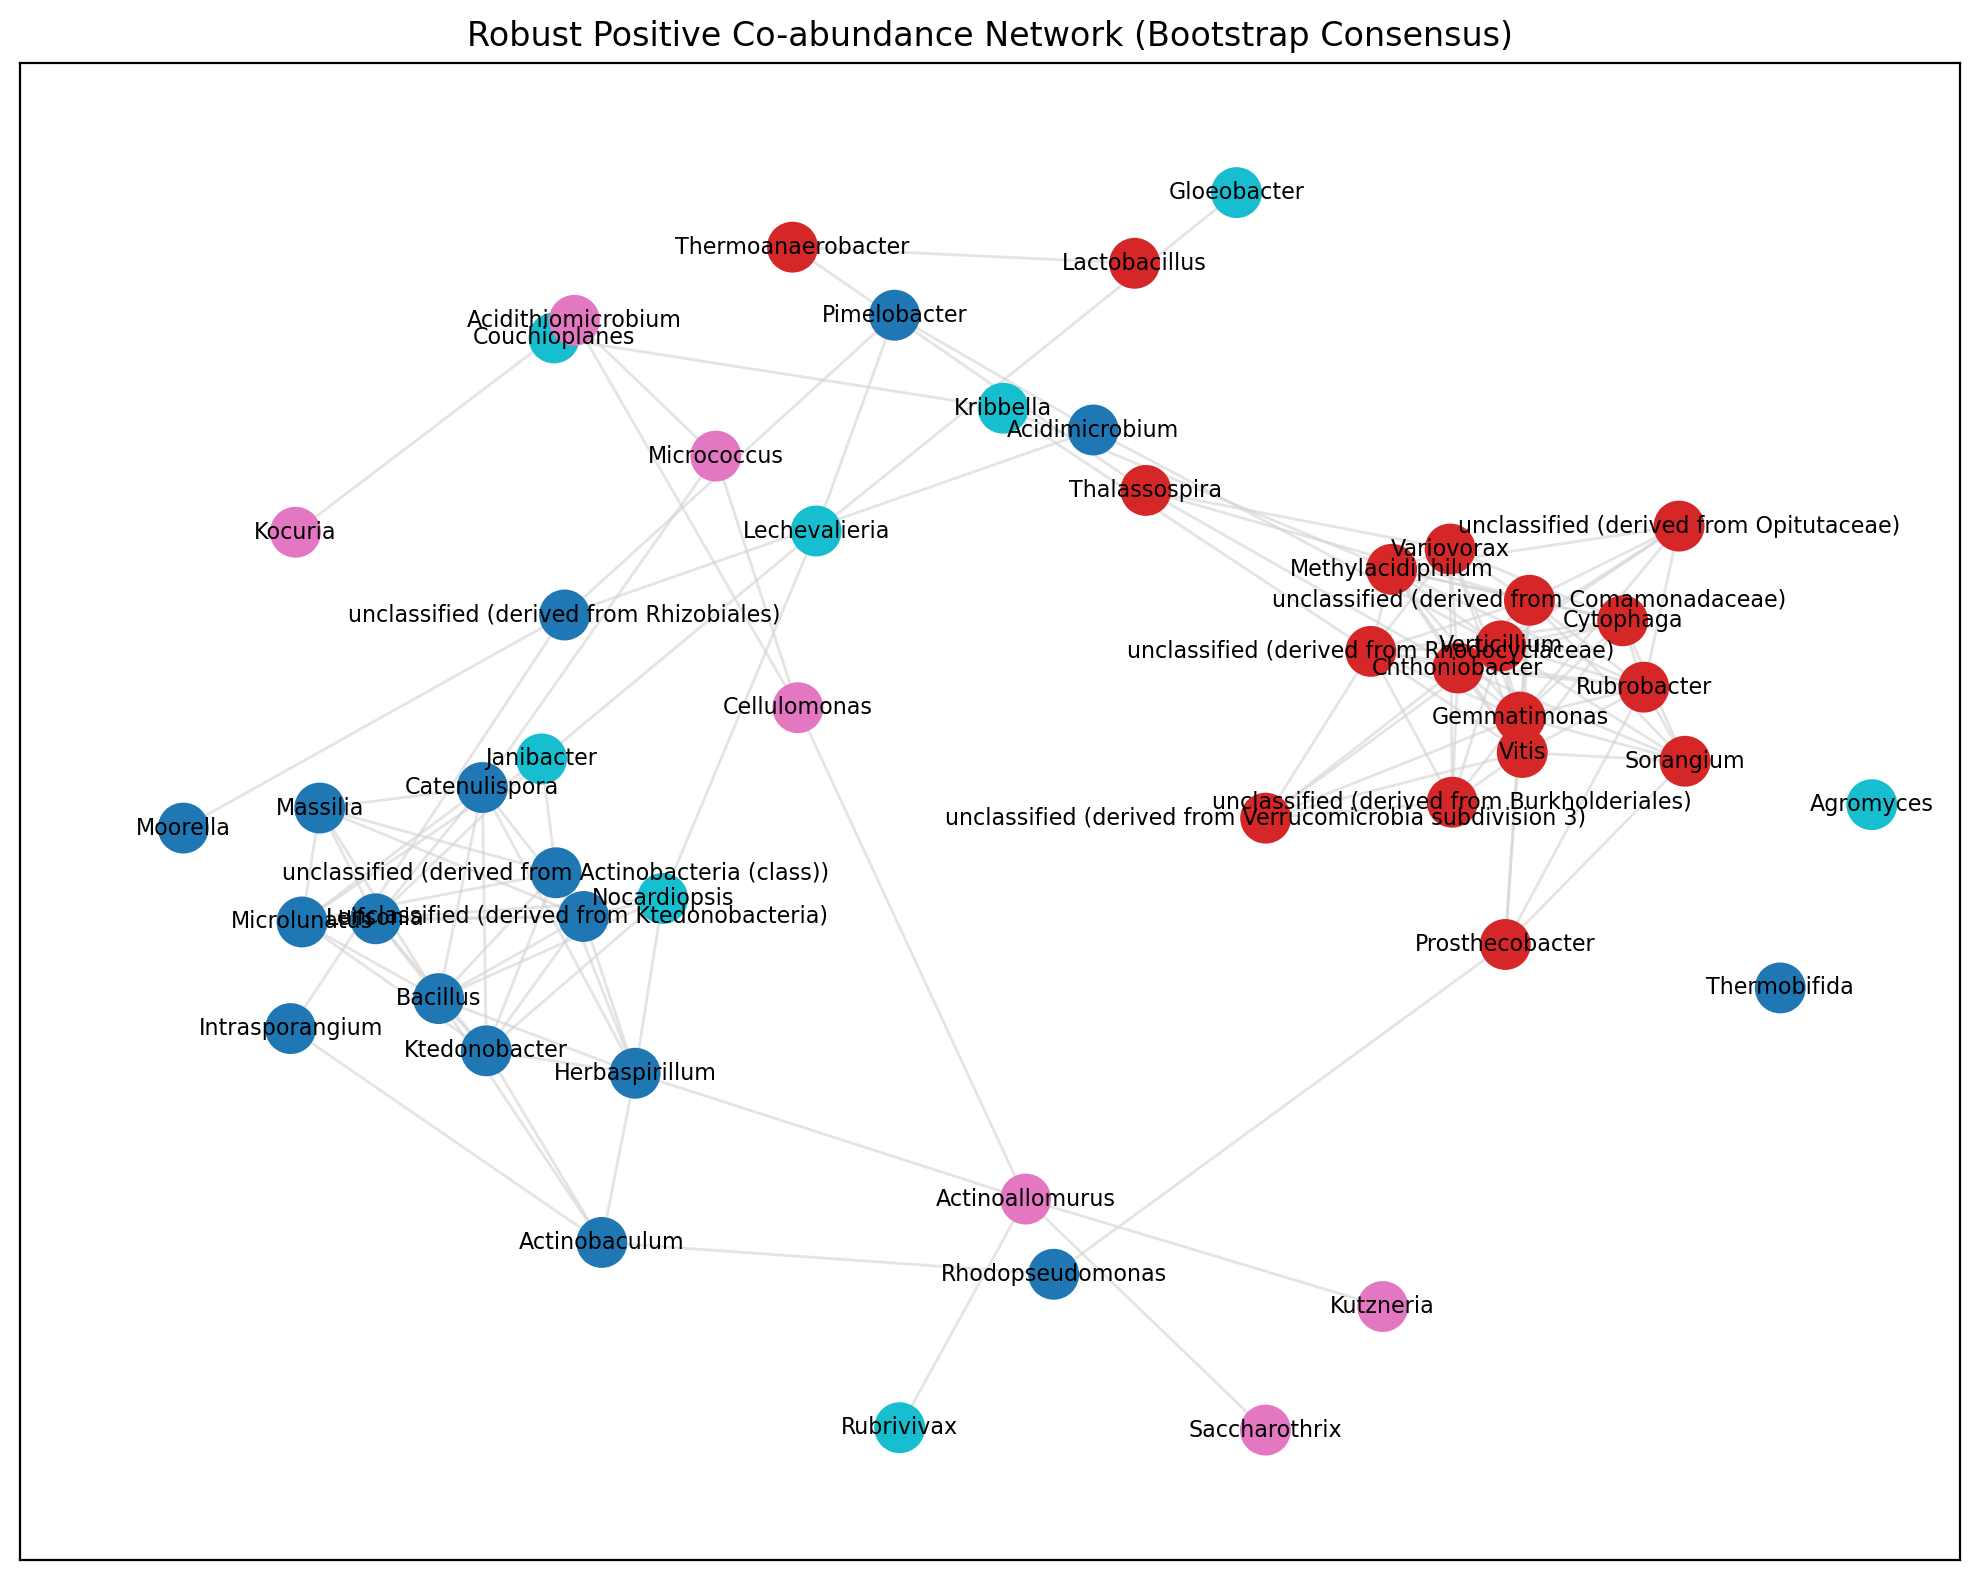

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.utils import resample
import networkx as nx

# ----------------------------
# 1) Load + pick columns
# ----------------------------
path = "/Users/kayadetunji/Downloads/soil study/raw data_taxonomy_CFC.xlsx"
df = pd.read_excel(path)

tax_cols = ['domain', 'phylum', 'className', 'order', 'family', 'genus']
sample_cols = [c for c in df.columns if c not in tax_cols]

taxa = df[tax_cols].fillna("Unclassified")
counts = df[sample_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# ----------------------------
# 2) Prevalence filter (robustness)
# ----------------------------
min_prev = 3
prev_mask = (counts > 0).sum(axis=1) >= min_prev
counts_f = counts.loc[prev_mask].copy()
taxa_f = taxa.loc[prev_mask].copy()

# collapse by genus if you have duplicate genus rows (optional but often important)
# (sum counts across rows that share same genus)
counts_f.index = taxa_f['genus'].values
counts_f = counts_f.groupby(counts_f.index).sum()

print("Taxa after prevalence + genus collapse:", counts_f.shape[0])

# ----------------------------
# 3) CLR transform (compositional aware)
# ----------------------------
def clr_transform(df_counts, pseudocount=1.0):
    X = np.log(df_counts + pseudocount)
    return X.sub(X.mean(axis=0), axis=1)  # center per sample

X_clr = clr_transform(counts_f)

# OPTIONAL: cap to top N taxa by variance (for readability, like your first code)
use_topN = True
topN = 50
if use_topN and X_clr.shape[0] > topN:
    var = X_clr.var(axis=1)
    keep = var.sort_values(ascending=False).head(topN).index
    X_clr = X_clr.loc[keep]
    print("Taxa after top-variance cap:", X_clr.shape[0])

# ----------------------------
# 4) Bootstrap consensus (POSITIVE ONLY)
# ----------------------------
n_boot = 100
r_threshold = 0.5       # "strong positive correlation" definition
consensus_keep = 0.5    # edge must appear in >=70% bootstraps to be kept

taxa_names = X_clr.index.to_list()
n_taxa = len(taxa_names)

# We bootstrap samples (columns) by resampling sample indices with replacement
X = X_clr.T  # samples x taxa
consensus = np.zeros((n_taxa, n_taxa), dtype=float)

for b in range(n_boot):
    X_res = resample(X, replace=True, n_samples=X.shape[0], random_state=42 + b)
    corr, _ = spearmanr(X_res, axis=0)
    corr = np.nan_to_num(corr)

    # POSITIVE ONLY
    adj = (corr >= r_threshold).astype(int)
    consensus += adj

consensus /= n_boot

# remove diagonal for meaningful density calculations
np.fill_diagonal(consensus, 0)

# ----------------------------
# 5) Dendrogram on (1 - consensus)
# ----------------------------
dist = 1 - consensus
dist_array = squareform(dist, checks=False)
Z = linkage(dist_array, method='complete')

plt.figure(figsize=(12, 6), dpi=200)
dendrogram(Z, labels=taxa_names, leaf_rotation=90, leaf_font_size=7)
plt.title("Dendrogram (Distance = 1 - Positive-edge Consensus Probability)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# choose number of modules (k) like your first code
k = 4 if n_taxa >= 30 else max(2, int(np.ceil(n_taxa / 5)))
module_labels = fcluster(Z, k, criterion='maxclust')
module_map = {taxa_names[i]: int(module_labels[i]) for i in range(n_taxa)}

# ----------------------------
# 6) Network from consensus edges
# ----------------------------
G = nx.Graph()
for g in taxa_names:
    G.add_node(g, module=module_map[g])

# Add edges where consensus >= 0.7
for i in range(n_taxa):
    for j in range(i + 1, n_taxa):
        p = consensus[i, j]
        if p >= consensus_keep:
            # store consensus probability as weight
            G.add_edge(taxa_names[i], taxa_names[j], weight=float(p))

# Report density (excluding diagonal)
possible_edges = n_taxa * (n_taxa - 1) / 2
print("Edges kept:", G.number_of_edges(), "out of", int(possible_edges),
      "=> density", G.number_of_edges() / possible_edges)

# ----------------------------
# 7) Plot network
# ----------------------------
plt.figure(figsize=(10, 8), dpi=200)
pos = nx.spring_layout(G, seed=42, k=0.5)

node_modules = [d['module'] for _, d in G.nodes(data=True)]
# Draw edges
nx.draw_networkx_edges(
    G, pos,
    edge_color="lightgray",
    alpha=0.6
)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_modules,
    cmap=plt.cm.tab10,
    node_size=300
)

# Draw labels
nx.draw_networkx_labels(
    G, pos,
    font_size=8
)
plt.title("Robust Positive Co-abundance Network (Bootstrap Consensus)")
plt.tight_layout()
plt.show()

# ----------------------------
# 8) Save module labels
# ----------------------------
# module_df = pd.DataFrame({"taxa": taxa_names, "module": node_modules})
# module_df.to_csv("taxa_modules.csv", index=False)

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# Import MDSS
from mdss.MDSS import MDSS
from mdss.ScoringFunctions.Bernoulli import Bernoulli

# ==========================================
# 1. SETUP & PREPROCESSING
# ==========================================
print("--- 1. Loading & Preprocessing ---")
# Load Data
tax_df = pd.read_excel('/Users/kayadetunji/Documents/DM_work/raw data_taxonomy_CFC.xlsx', sheet_name='taxonomy')
chem_df = pd.read_excel('/Users/kayadetunji/Documents/DM_work/raw data_taxonomy_CFC.xlsx', sheet_name='properties')

# Metadata Setup
gz_cols = ['GZ1', 'GZ2', 'GZ3', 'GZ4']
ag_cols = ['AG1', 'AG2', 'AG3', 'AG4']
all_samples = gz_cols + ag_cols

# Filter Rare Taxa
counts = tax_df[all_samples]
mask = (counts > 0).sum(axis=1) >= 3
df_clean = tax_df[mask].reset_index(drop=True)

# Correct CLR Transformation (Centered per Sample)
def clr_transform(count_df):
    # Log transform (with pseudocount)
    df_log = np.log(count_df + 1)
    # Calculate geometric mean of each SAMPLE (row)
    # axis=1 calculates the mean across columns for each row
    sample_geometric_means = df_log.mean(axis=1)
    # Subtract sample mean from each value in that sample
    # axis=0 aligns the subtraction by index
    return df_log.sub(sample_geometric_means, axis=0)

df_clr = clr_transform(df_clean[all_samples].T) # Transpose first so Rows=Samples
# df_clr is now [Samples x Genera]

# ==========================================
# 2. ROBUST NETWORK (Positive Corr + Average Linkage)
# ==========================================
print("--- 2. Constructing Robust Network (Bootstrapped) ---")
n_boot = 50
threshold_rho = 0.6
n_genera = df_clr.shape[1]
consensus_matrix = np.zeros((n_genera, n_genera))

for i in range(n_boot):
    # Resample SAMPLES (Rows of df_clr)
    # df_resampled will be [Samples x Genera]
    df_resampled = resample(df_clr, replace=True, random_state=i)
    
    # Calculate Spearman Correlation between GENERA (Columns)
    # axis=0 (default) treats columns as variables
    corr, _ = spearmanr(df_resampled, axis=0)
    corr = np.nan_to_num(corr)
    
    # POSITIVE CORRELATION ONLY (Cooperative Guilds)
    adj = (corr >= threshold_rho).astype(int)
    consensus_matrix += adj

# Consensus Threshold (Keep edges present in >70% of bootstraps)
final_adjacency = (consensus_matrix / n_boot >= 0.7).astype(int)
np.fill_diagonal(final_adjacency, 1)

# Clustering (Average Linkage on Correlation Distance)
# Convert consensus to distance
dist_matrix = 1 - (consensus_matrix / n_boot)
dist_matrix = np.clip(dist_matrix, 0, 1) 
dist_array = squareform(dist_matrix, checks=False)

# Average Linkage (UPGMA) - Valid for non-Euclidean
Z = linkage(dist_array, method='average')

# Define Modules (Cut tree to get ~4-6 modules)
cluster_labels = fcluster(Z, t=4, criterion='maxclust')
df_clean['Module_ID'] = cluster_labels
print(f"Identified {len(np.unique(cluster_labels))} Modules.")

# ==========================================
# 3. FEATURE ENGINEERING (The \"Rich\" Space)
# ==========================================
print("--- 3. Creating Rich Feature Matrix ---")
features_df = pd.DataFrame(index=all_samples)

# A. Module Eigengenes + Hub Identification
pca = PCA(n_components=1)
hub_taxa = {}

for mod_id in np.unique(cluster_labels):
    # Get Genera in this module
    # df_clr is [Samples x Genera], so we select columns
    mod_indices = np.where(cluster_labels == mod_id)[0]
    mod_data = df_clr.iloc[:, mod_indices] # Samples x Genera in Module
    
    # Calculate Eigengene (PC1)
    pc1 = pca.fit_transform(StandardScaler().fit_transform(mod_data))
    eig_col = f"Mod_{mod_id}_Score"
    features_df[eig_col] = pc1.flatten()
    
    # Identify HUB (Genus most correlated with Eigengene)
    corrs = mod_data.corrwith(pd.Series(pc1.flatten(), index=mod_data.index))
    hub_idx = np.argmax(np.abs(corrs)) # Index within the module subset
    hub_name = mod_data.columns[hub_idx] # Original column name (Genus)
    hub_taxa[mod_id] = hub_name
    
    # Add Hub Abundance to Features
    features_df[f"Hub_{hub_name}_Abund"] = mod_data[hub_name]

print(f"Identified Hubs: {hub_taxa}")

# B. Functional Scores (Database Simulation)
trait_db = {
    'Azospirillum': 'N_Fixation', 'Nitrosomonas': 'N_Fixation', 'Burkholderia': 'N_Fixation',
    'Bacillus': 'Stress_Tol', 'Arthrobacter': 'Stress_Tol', 'Solibacter': 'Acid_Tol',
    'Gemmatimonas': 'Rhizo_Stab', 'Rubrobacter': 'Stress_Tol'
}
for func in set(trait_db.values()):
    func_genera = [g for g, f in trait_db.items() if f == func]
    # Check which of these are actually in our cleaned dataset
    valid_genera = [g for g in func_genera if g in df_clr.columns]
    if valid_genera:
        features_df[f"Func_{func}"] = df_clr[valid_genera].sum(axis=1)

# C. Chemistry
chem_t = chem_df.set_index('Variable').T
features_df['pH'] = chem_t.loc[all_samples, 'pH'].astype(float)
features_df['Nitrate'] = chem_t.loc[all_samples, 'N–NO3(mg/kg)'].astype(float)

# ==========================================
# 4. BINNING & MDSS SCAN
# ==========================================
print("--- 4. Binning & MDSS Scanning ---")

# BINNING
features_bin = pd.DataFrame(index=features_df.index)
for col in features_df.columns:
    median_val = features_df[col].median()
    features_bin[f"{col}_High"] = (features_df[col] > median_val).astype(int)
    features_bin[f"{col}_Low"] = (features_df[col] <= median_val).astype(int)

# Define Outcome (Degraded Soil)
outcome = pd.Series([0,0,0,0,1,1,1,1], index=all_samples) # GZ=0, AG=1
expectation = pd.Series([0.5]*8, index=all_samples)

# Run MDSS
scanner = MDSS(Bernoulli(direction='positive'))
subset, score = scanner.scan(
    coordinates=features_bin,
    outcomes=outcome,
    expectations=expectation,
    penalty=1.0,
    num_iters=20,
    mode='binary',
    verbose=False
)

print(f"\nMDSS Score: {score:.4f}")
print("Top Combinatorial Rule predicting Soil Degradation:")
print(subset)

# Visualizing the Modules (Optional but recommended)
print("\n--- Module Summary ---")
for mod_id in np.unique(cluster_labels):
    size = np.sum(cluster_labels == mod_id)
    hub = hub_taxa[mod_id]
    print(f"Module {mod_id}: {size} Genera. Hub: {hub}")

--- 1. Loading & Preprocessing ---
--- 2. Constructing Robust Network (Bootstrapped) ---
Identified 4 Modules.
--- 3. Creating Rich Feature Matrix ---
Identified Hubs: {1: 135, 2: 200, 3: 115, 4: 53}
--- 4. Binning & MDSS Scanning ---

MDSS Score: 1.7726
Top Combinatorial Rule predicting Soil Degradation:
{'Mod_4_Score_High': [1]}

--- Module Summary ---
Module 1: 61 Genera. Hub: 135
Module 2: 81 Genera. Hub: 200
Module 3: 86 Genera. Hub: 115
Module 4: 70 Genera. Hub: 53


--- Constructing Robust Network (Bootstrapped) ---
Identified 4 Modules.


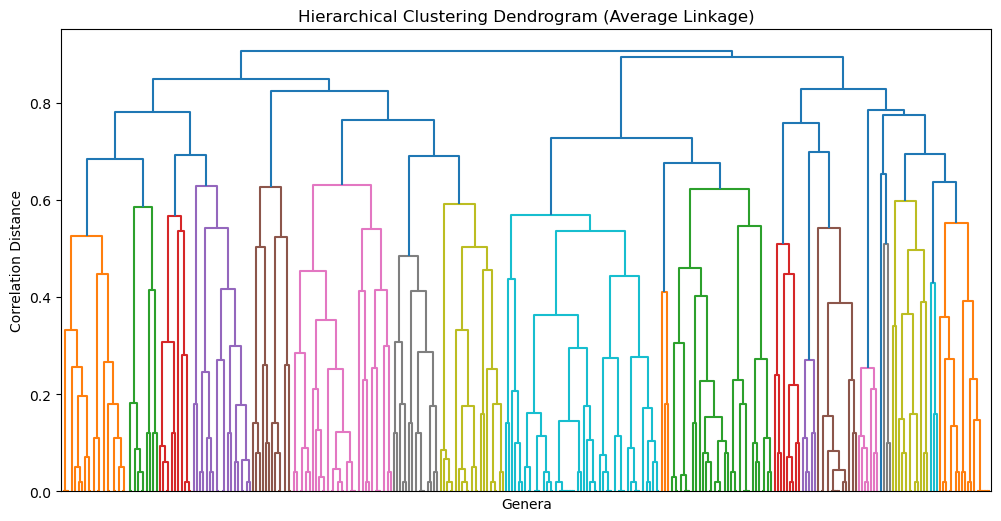

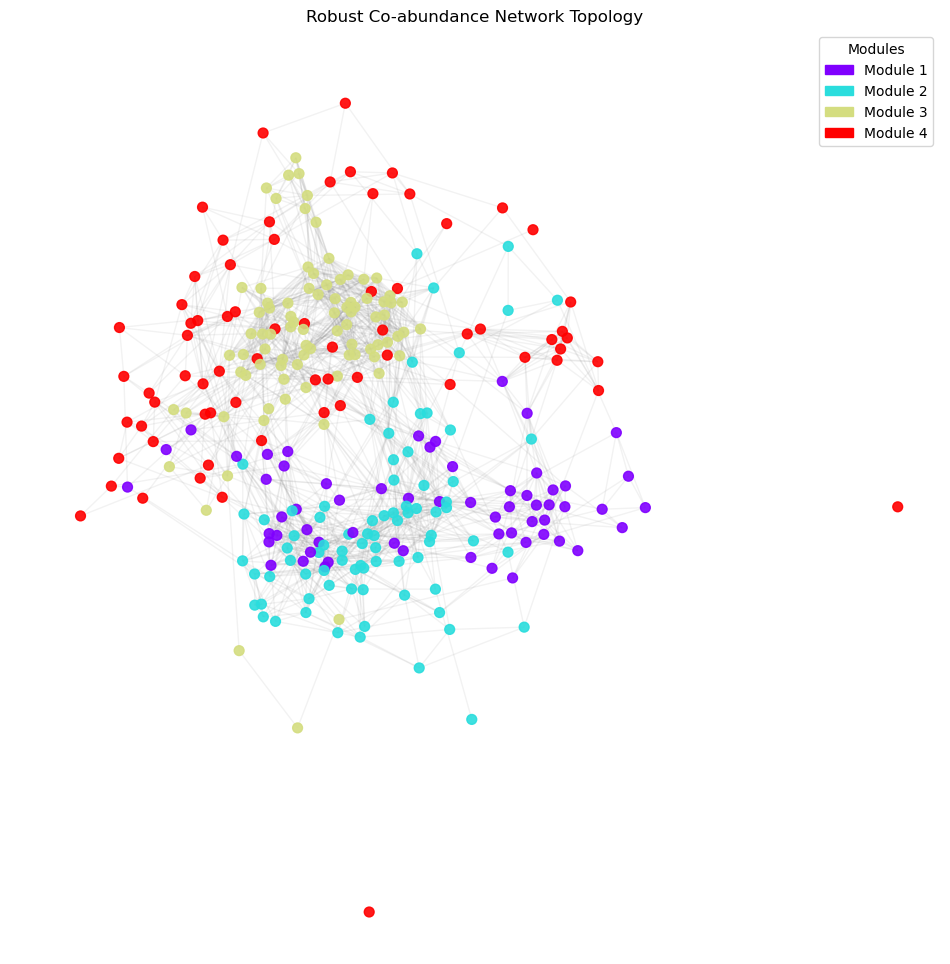

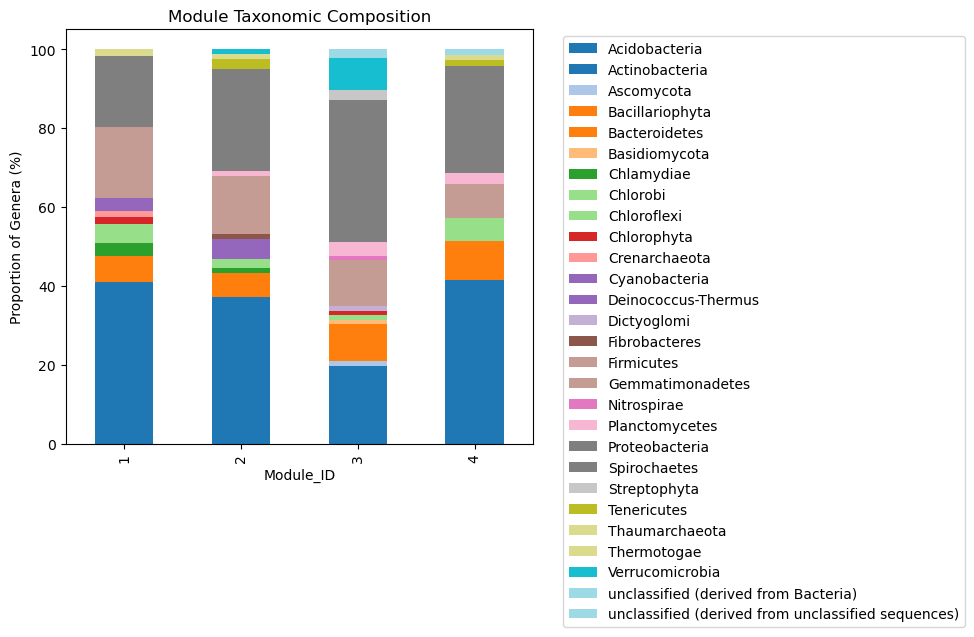

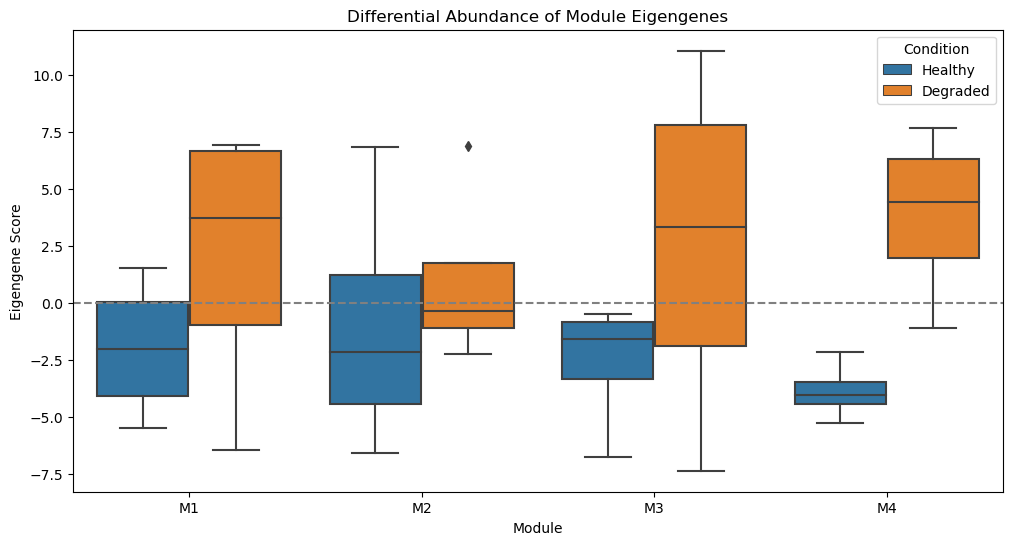

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# ==========================================
# 1. SETUP & PREPROCESSING
# ==========================================
# Load Data
tax_df = pd.read_excel('/Users/kayadetunji/Documents/DM_work/raw data_taxonomy_CFC.xlsx', sheet_name='taxonomy')
chem_df = pd.read_excel('/Users/kayadetunji/Documents/DM_work/raw data_taxonomy_CFC.xlsx', sheet_name='properties')
# Metadata Setup
gz_cols = ['GZ1', 'GZ2', 'GZ3', 'GZ4']
ag_cols = ['AG1', 'AG2', 'AG3', 'AG4']
all_samples = gz_cols + ag_cols

# Filter Rare Taxa
counts = tax_df[all_samples]
mask = (counts > 0).sum(axis=1) >= 3
df_clean = tax_df[mask].reset_index(drop=True)

# Correct CLR Transformation (Centered per Sample)
def clr_transform(count_df):
    df_log = np.log(count_df + 1)
    # Calculate geometric mean of each SAMPLE (row)
    sample_geometric_means = df_log.mean(axis=1)
    # Subtract sample mean from each value in that sample
    return df_log.sub(sample_geometric_means, axis=0)

df_clr = clr_transform(df_clean[all_samples].T) # Transpose: Rows=Samples

# ==========================================
# 2. ROBUST NETWORK (Positive Corr + Average Linkage)
# ==========================================
print("--- Constructing Robust Network (Bootstrapped) ---")
n_boot = 50
threshold_rho = 0.6
n_genera = df_clr.shape[1]
consensus_matrix = np.zeros((n_genera, n_genera))

for i in range(n_boot):
    # Resample SAMPLES (Rows of df_clr)
    df_resampled = resample(df_clr, replace=True, random_state=i)
    
    # Calculate Spearman Correlation between GENERA (Columns)
    corr, _ = spearmanr(df_resampled, axis=0)
    corr = np.nan_to_num(corr)
    
    # POSITIVE CORRELATION ONLY (Cooperative Guilds)
    adj = (corr >= threshold_rho).astype(int)
    consensus_matrix += adj

# Consensus Threshold (Keep edges present in >70% of bootstraps)
final_adjacency = (consensus_matrix / n_boot >= 0.7).astype(int)
np.fill_diagonal(final_adjacency, 1)

# Clustering (Average Linkage on Correlation Distance)
dist_matrix = 1 - (consensus_matrix / n_boot)
dist_matrix = np.clip(dist_matrix, 0, 1) 
dist_array = squareform(dist_matrix, checks=False)

# Average Linkage (UPGMA)
Z = linkage(dist_array, method='average')

# Define Modules
cluster_labels = fcluster(Z, t=4, criterion='maxclust')
df_clean['Module_ID'] = cluster_labels
print(f"Identified {len(np.unique(cluster_labels))} Modules.")

# ==========================================
# 3. VISUALIZATION
# ==========================================

# A. DENDROGRAM
plt.figure(figsize=(12, 6))
dendrogram(Z, no_labels=True, color_threshold=0.7*max(Z[:,2]))
plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
plt.xlabel("Genera")
plt.ylabel("Correlation Distance")
plt.show()

# B. NETWORK TOPOLOGY
G = nx.from_numpy_array(final_adjacency)
G.remove_edges_from(nx.selfloop_edges(G))

module_map = df_clean['Module_ID'].to_dict()
unique_modules = sorted(df_clean['Module_ID'].unique())
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_modules)))
color_map = {mod: color for mod, color in zip(unique_modules, colors)}
node_colors = [color_map[module_map.get(i, 1)] for i in G.nodes()]

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.15, seed=42)
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='grey')
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=50, alpha=0.9)
patches = [mpatches.Patch(color=color_map[i], label=f"Module {i}") for i in unique_modules]
plt.legend(handles=patches, title="Modules")
plt.title("Robust Co-abundance Network Topology")
plt.axis('off')
plt.show()

# C. MODULE COMPOSITION (Stacked Bar)
mod_comp = pd.crosstab(df_clean['Module_ID'], df_clean['phylum'])
mod_comp_pct = mod_comp.div(mod_comp.sum(axis=1), axis=0) * 100
ax = mod_comp_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title("Module Taxonomic Composition")
plt.ylabel("Proportion of Genera (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# D. EIGENGENE RESPONSE
pca = PCA(n_components=1)
eigengenes = pd.DataFrame(index=all_samples)
for mod_id in unique_modules:
    mod_indices = np.where(cluster_labels == mod_id)[0]
    mod_data = df_clr.iloc[:, mod_indices]
    if mod_data.shape[1] > 0:
        pc1 = pca.fit_transform(StandardScaler().fit_transform(mod_data))
        eigengenes[f"M{mod_id}"] = pc1.flatten()

eigengenes['Condition'] = ['Healthy']*4 + ['Degraded']*4
plot_data = eigengenes.melt(id_vars='Condition', var_name='Module', value_name='Eigengene Score')

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_data, x='Module', y='Eigengene Score', hue='Condition')
plt.title("Differential Abundance of Module Eigengenes")
plt.axhline(0, linestyle='--', color='grey')
plt.show()

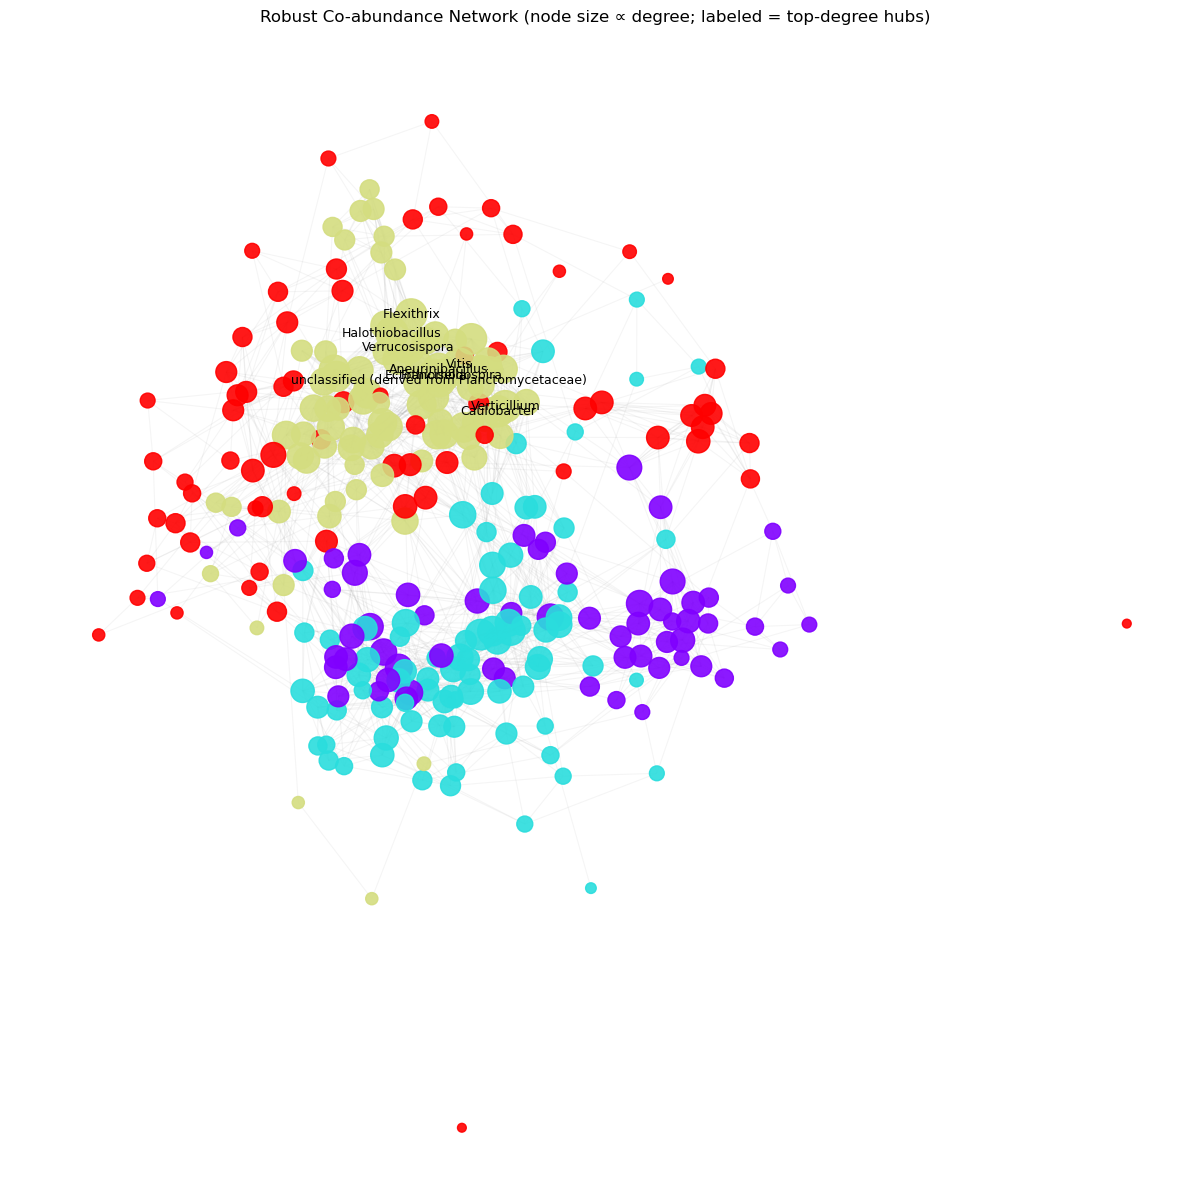

In [44]:
# ==========================================
# 4. NETWORK METRICS + HUB/CONNECTOR PLOT
# ==========================================
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import os

# --- Node metadata (assumes df_clean rows correspond to nodes 0..n-1)
node_meta = df_clean[['genus','phylum','Module_ID']].copy()
node_meta['node_id'] = node_meta.index
node_meta = node_meta.set_index('node_id')

# --- Core centrality metrics
deg = dict(G.degree())
deg_cent = nx.degree_centrality(G)
bet = nx.betweenness_centrality(G, normalized=True)
clo = nx.closeness_centrality(G)
eig = nx.eigenvector_centrality_numpy(G)  # works even if graph isn't fully connected
clust = nx.clustering(G)

# --- Zi (within-module z-score) and Pi (participation coefficient)
modules = node_meta['Module_ID'].to_dict()
unique_modules = sorted(node_meta['Module_ID'].unique())

module_nodes = {m: [n for n in G.nodes() if modules.get(n) == m] for m in unique_modules}

k_is = {n: {m: 0 for m in unique_modules} for n in G.nodes()}
for n in G.nodes():
    for nbr in G.neighbors(n):
        m = modules.get(nbr)
        if m in k_is[n]:
            k_is[n][m] += 1

k_in = {n: k_is[n][modules.get(n)] for n in G.nodes()}

Zi = {}
for m in unique_modules:
    nodes_m = module_nodes[m]
    vals = np.array([k_in[n] for n in nodes_m], dtype=float)
    mu = vals.mean() if len(vals) else 0.0
    sd = vals.std(ddof=0) if len(vals) else 0.0
    for n in nodes_m:
        Zi[n] = (k_in[n] - mu) / sd if sd > 0 else 0.0

Pi = {}
for n in G.nodes():
    k = deg[n]
    if k == 0:
        Pi[n] = 0.0
    else:
        Pi[n] = 1.0 - sum((k_is[n][m] / k) ** 2 for m in unique_modules)

# --- Assemble table
metrics = pd.DataFrame({
    'genus': node_meta['genus'],
    'phylum': node_meta['phylum'],
    'Module_ID': node_meta['Module_ID'],
    'degree': pd.Series(deg),
    'degree_centrality': pd.Series(deg_cent),
    'betweenness': pd.Series(bet),
    'closeness': pd.Series(clo),
    'eigenvector': pd.Series(eig),
    'clustering_coeff': pd.Series(clust),
    'Zi_within_module': pd.Series(Zi),
    'Pi_participation': pd.Series(Pi),
}).fillna(0)

# --- Define hubs/bridges (example thresholds)
metrics['hub_top10pct_degree'] = metrics['degree'] >= metrics['degree'].quantile(0.90)
metrics['bridge_top10pct_betweenness'] = metrics['betweenness'] >= metrics['betweenness'].quantile(0.90)
metrics['connector_Pi_ge_0_6'] = metrics['Pi_participation'] >= 0.6

# Save metrics
# metrics.sort_values('degree', ascending=False).to_csv("network_node_metrics.csv", index_label="node_id")

# --- Plot: node size proportional to degree, label top hubs by degree
top_hubs = metrics.sort_values(['degree','eigenvector'], ascending=False).head(10)
hub_nodes = top_hubs.index.tolist()
hub_labels = {n: metrics.loc[n, 'genus'] for n in hub_nodes}

deg_values = np.array([deg[n] for n in G.nodes()], dtype=float)
node_sizes = 40 + (deg_values / max(deg_values.max(), 1)) * 500

plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(G, pos, alpha=0.08, edge_color='grey', width=0.8)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, labels=hub_labels, font_size=9)
plt.title("Robust Co-abundance Network (node size ∝ degree; labeled = top-degree hubs)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [47]:
metrics.sort_values('degree', ascending=False).head(15)

,genus,phylum,Module_ID,degree,degree_centrality,betweenness,closeness,eigenvector,clustering_coeff,Zi_within_module,Pi_participation,hub_top10pct_degree,bridge_top10pct_betweenness,connector_Pi_ge_0_6
270,Vitis,Streptophyta,3,27,0.090909,0.008324,0.282015,0.209002,0.495726,1.790343,0.071331,True,False,False
268,Verrucosispora,Actinobacteria,3,27,0.090909,0.007105,0.285033,0.201037,0.427350,1.945868,0.000000,True,False,False
126,Halothiobacillus,Proteobacteria,3,27,0.090909,0.014396,0.288116,0.187867,0.407407,1.945868,0.000000,True,False,False
27,Aneurinibacillus,Firmicutes,3,26,0.087542,0.003720,0.281203,0.224420,0.569231,1.790343,0.000000,True,False,False
112,Francisella,Proteobacteria,3,26,0.087542,0.003720,0.281203,0.224420,0.569231,1.790343,0.000000,True,False,False
287,unclassified (derived from Planctomycetaceae),Planctomycetes,3,26,0.087542,0.003720,0.281203,0.224420,0.569231,1.790343,0.000000,True,False,False
99,Ectothiorhodospira,Proteobacteria,3,26,0.087542,0.003720,0.281203,0.224420,0.569231,1.790343,0.000000,True,False,False
269,Verticillium,Ascomycota,3,26,0.087542,0.017718,0.292137,0.171613,0.430769,0.857195,0.355030,True,False,False
61,Caulobacter,Proteobacteria,3,25,0.084175,0.010588,0.280933,0.173845,0.450000,0.857195,0.320000,True,False,False
111,Flexithrix,Bacteroidetes,3,25,0.084175,0.014682,0.282832,0.164004,0.383333,1.634819,0.000000,True,False,False


In [ ]:
# --- assumes you already built df_clean, df_clr, cluster_labels, metrics, etc. ---
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu, spearmanr
import numpy as np
import pandas as pd

# 1) Eigengenes
pca = PCA(n_components=1)
unique_modules = sorted(df_clean['Module_ID'].unique())
eig = pd.DataFrame(index=all_samples)

for m in unique_modules:
    idx = np.where(cluster_labels == m)[0]
    X = df_clr.iloc[:, idx]
    Xs = StandardScaler().fit_transform(X)
    eig[f"M{m}"] = pca.fit_transform(Xs).flatten()

eig['Condition'] = ['Healthy']*4 + ['Degraded']*4

# 1) Differences + effect sizes
eig_stats=[]
for m in unique_modules:
    H = eig.loc[eig['Condition']=='Healthy', f"M{m}"].astype(float)
    D = eig.loc[eig['Condition']=='Degraded', f"M{m}"].astype(float)
    U, p = mannwhitneyu(H, D, alternative='two-sided')
    delta = D.mean() - H.mean()
    pooled_sd = np.sqrt((H.var(ddof=1)+D.var(ddof=1))/2)
    d = delta/pooled_sd if pooled_sd>0 else np.nan
    rbc = 1 - (2*U)/(len(H)*len(D))   # rank-biserial
    eig_stats.append([f"M{m}", H.mean(), D.mean(), delta, d, rbc, p])

eig_stats_df = pd.DataFrame(eig_stats, columns=[
    'Module','Mean_Healthy','Mean_Degraded','Delta(D-H)','Cohen_d','Rank_biserial','p_MWU'
]).sort_values('p_MWU')

# 2) Drivers
drivers = eig_stats_df.copy()
drivers['Abs_Cohen_d'] = drivers['Cohen_d'].abs()
drivers['Direction'] = np.where(drivers['Delta(D-H)']>0, 'Higher in Degraded', 'Higher in Healthy')
drivers = drivers.sort_values(['Abs_Cohen_d','p_MWU'], ascending=[False, True])

# 3) Link hubs to module behavior
top_degree = metrics.sort_values(['degree','eigenvector'], ascending=False).head(15).copy()
top_degree['Module'] = top_degree['Module_ID'].map(lambda x: f"M{x}")
mod_map = eig_stats_df.set_index('Module')[['Delta(D-H)','Cohen_d','p_MWU']]
top_degree = top_degree.join(mod_map, on='Module')

# 4) Chemistry correlations (properties sheet: rows=Variable, cols=samples)
chem = chem_df[['Variable'] + all_samples].set_index('Variable').T
chem_corr_rows=[]
for m in unique_modules:
    for var in chem.columns:
        rho, p = spearmanr(eig[f"M{m}"], chem[var])
        chem_corr_rows.append([f"M{m}", var, rho, p])

chem_corr = pd.DataFrame(chem_corr_rows, columns=['Module','Soil_variable','Spearman_rho','p'])
chem_corr = chem_corr.sort_values('p').reset_index(drop=True)
m_tests = len(chem_corr)
chem_corr['BH_FDR_q'] = (chem_corr['p'] * m_tests / (np.arange(1, m_tests+1))).clip(upper=1.0)

# Save outputs
eig_stats_df.to_csv("/Users/kayadetunji/Documents/DM_work/module_eigengene_stats.csv", index=False)
drivers.to_csv("/Users/kayadetunji/Documents/DM_work/module_drivers_by_effect.csv", index=False)
top_degree.to_csv("/Users/kayadetunji/Documents/DM_work/top_degree_hubs_linked.csv", index=False)
chem_corr.to_csv("/Users/kayadetunji/Documents/DM_work/module_eigengene_chemistry.csv", index=False)

# # --- Plot: eigengenes
# pca = PCA(n_components=2)
# eig = eig_stats_df[['Module','Mean_Healthy','Mean_Degraded']]
# eig['Module'] = eig['Module'].map(lambda x: f"M{x}")
# eig['Condition'] = ['Healthy']*4 + ['Degraded']*4
# eig['x'] = pca.fit_transform(eig[['Mean_Healthy','Mean_Degraded']]).flatten()
# eig['y'] = pca.fit_transform(eig[['Mean_Healthy','Mean_Degraded']]).flatten()

# plt.figure(figsize=(8, 8))
# for c in eig['Condition'].unique():
#     plt.scatter(eig.loc[eig['Condition']==c, 'x'], eig.loc[eig['Condition']==c, 'y'], label=c)
# plt.title("Eigengene Response", fontsize=16)
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.legend()
# plt.tight_layout()
# plt.show()

,Module,Mean_Healthy,Mean_Degraded,Delta(D-H),Cohen_d,Rank_biserial,p_MWU
3,M4,-3.850289,3.850289,7.700577,2.703558,1.000,0.028571
2,M3,-2.597383,2.597383,5.194766,0.859741,0.500,0.342857
0,M1,-1.991177,1.991177,3.982355,0.802719,0.375,0.485714
1,M2,-1.009511,1.009511,2.019022,0.405685,0.375,0.485714


,node_id,genus,phylum,Module_ID,degree,degree_centrality,betweenness,closeness,eigenvector,clustering_coeff,Zi_within_module,Pi_participation,hub_top10pct_degree,bridge_top10pct_betweenness,connector_Pi_ge_0_6
0,270,Vitis,Streptophyta,3,27,0.090909,0.008324,0.282015,0.209002,0.495726,1.790343,0.071331,True,False,False
1,268,Verrucosispora,Actinobacteria,3,27,0.090909,0.007105,0.285033,0.201037,0.427350,1.945868,0.000000,True,False,False
2,126,Halothiobacillus,Proteobacteria,3,27,0.090909,0.014396,0.288116,0.187867,0.407407,1.945868,0.000000,True,False,False
3,99,Ectothiorhodospira,Proteobacteria,3,26,0.087542,0.003720,0.281203,0.224420,0.569231,1.790343,0.000000,True,False,False
4,112,Francisella,Proteobacteria,3,26,0.087542,0.003720,0.281203,0.224420,0.569231,1.790343,0.000000,True,False,False
5,27,Aneurinibacillus,Firmicutes,3,26,0.087542,0.003720,0.281203,0.224420,0.569231,1.790343,0.000000,True,False,False
6,287,unclassified (derived from Planctomycetaceae),Planctomycetes,3,26,0.087542,0.003720,0.281203,0.224420,0.569231,1.790343,0.000000,True,False,False
7,269,Verticillium,Ascomycota,3,26,0.087542,0.017718,0.292137,0.171613,0.430769,0.857195,0.355030,True,False,False
8,61,Caulobacter,Proteobacteria,3,25,0.084175,0.010588,0.280933,0.173845,0.450000,0.857195,0.320000,True,False,False
9,111,Flexithrix,Bacteroidetes,3,25,0.084175,0.014682,0.282832,0.164004,0.383333,1.634819,0.000000,True,False,False


Variable,pH,S (mg/kg),TC (mg/kg),P (mg/kg),K (mg/kg),N–NO3(mg/kg),N–NH4(mg/kg),OC (%),OM (%)
M1,-0.333333,0.081832,-0.215573,-0.523810,-0.443122,-0.214286,0.119048,-0.287430,-0.095238
M2,-0.547619,-0.327327,-0.467074,-0.142857,-0.562884,-0.452381,0.071429,-0.395217,-0.214286
M3,-0.452381,0.027277,-0.347312,-0.476190,-0.503003,-0.333333,0.285714,-0.299407,-0.119048
M4,-0.547619,-0.436436,-0.562884,-0.357143,-0.586837,-0.857143,0.761905,-0.598813,-0.690476


Variable,pH,S (mg/kg),TC (mg/kg),P (mg/kg),K (mg/kg),N–NO3(mg/kg),N–NH4(mg/kg),OC (%),OM (%)
M1,0.419753,0.847249,0.608149,0.182721,0.271502,0.610344,0.778886,0.490015,0.822505
M2,0.160026,0.428692,0.243270,0.735765,0.146332,0.260405,0.866526,0.332517,0.610344
M3,0.260405,0.948881,0.399264,0.232936,0.203877,0.419753,0.492726,0.471261,0.778886
M4,0.160026,0.279658,0.146332,0.385121,0.126199,0.006530,0.028005,0.116754,0.057990


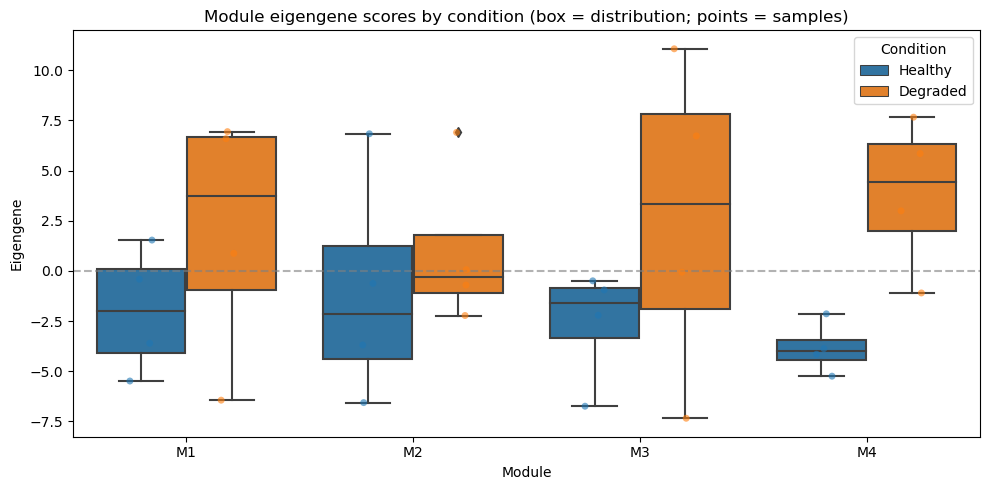

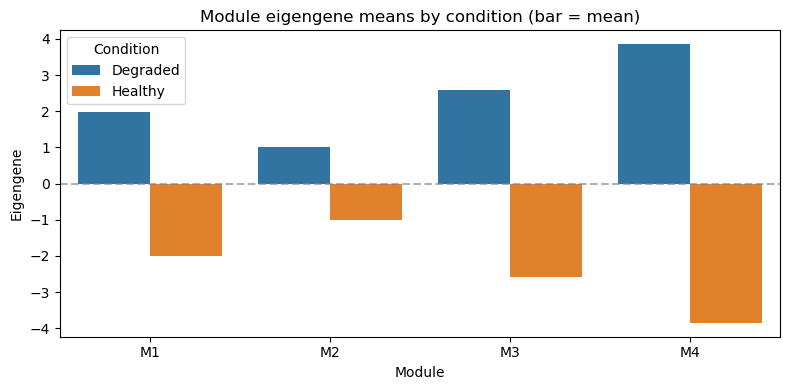

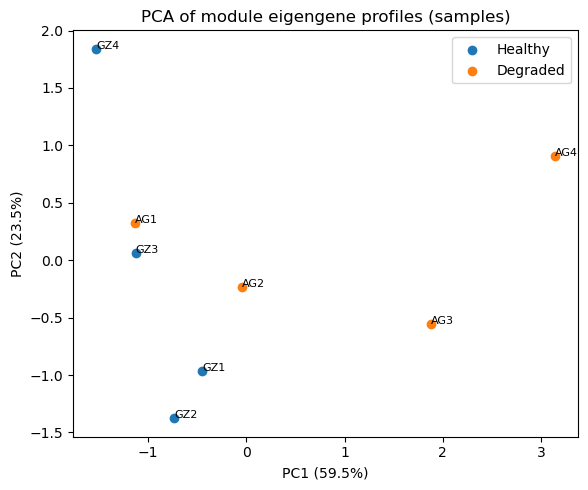

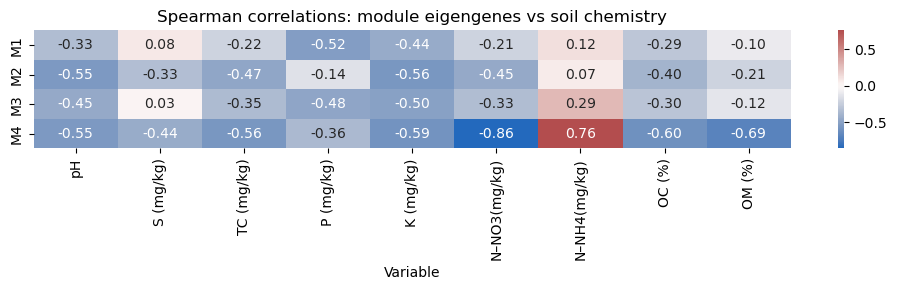

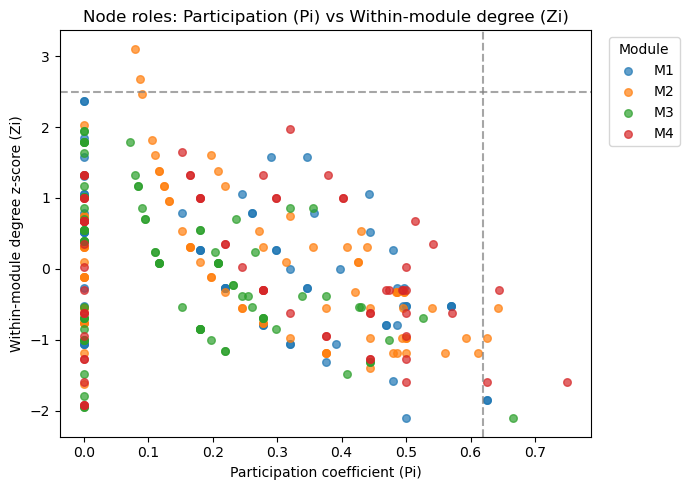

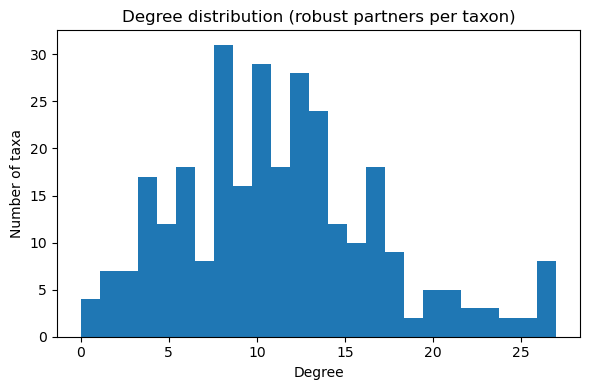

In [55]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from scipy.stats import spearmanr, mannwhitneyu
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
# from caas_jupyter_tools import display_dataframe_to_user

# -----------------------------
# 0) Load data
# -----------------------------
path="/Users/kayadetunji/Documents/DM_work/raw data_taxonomy_CFC.xlsx"
tax_df = pd.read_excel(path, sheet_name="taxonomy")
chem_df = pd.read_excel(path, sheet_name="properties")

gz_cols=['GZ1','GZ2','GZ3','GZ4']
ag_cols=['AG1','AG2','AG3','AG4']
all_samples=gz_cols+ag_cols

# -----------------------------
# 1) Preprocess (taxa-centric)
# -----------------------------
counts = tax_df[all_samples]
mask = (counts > 0).sum(axis=1) >= 3
df_clean = tax_df.loc[mask].reset_index(drop=True)

def clr_transform(count_df: pd.DataFrame) -> pd.DataFrame:
    df_log = np.log(count_df + 1)
    return df_log.sub(df_log.mean(axis=1), axis=0)

df_clr = clr_transform(df_clean[all_samples].T)  # rows=samples, cols=taxa

# -----------------------------
# 2) Robust positive co-abundance network + modules
# -----------------------------
n_boot=50
threshold_rho=0.6
consensus = np.zeros((df_clr.shape[1], df_clr.shape[1]), dtype=float)

for i in range(n_boot):
    rs = resample(df_clr, replace=True, random_state=i)     # resample samples
    corr, _ = spearmanr(rs, axis=0)                         # correlate taxa
    corr = np.nan_to_num(corr)
    consensus += (corr >= threshold_rho).astype(int)

edge_freq = consensus / n_boot
final_adj = (edge_freq >= 0.7).astype(int)
np.fill_diagonal(final_adj, 0)

dist = np.clip(1 - edge_freq, 0, 1)
Z = linkage(squareform(dist, checks=False), method="average")
cluster_labels = fcluster(Z, t=4, criterion="maxclust")
df_clean["Module_ID"] = cluster_labels
unique_modules = sorted(df_clean["Module_ID"].unique())

G = nx.from_numpy_array(final_adj)
G.remove_edges_from(nx.selfloop_edges(G))

# -----------------------------
# 3) Node-level metrics (hubs, connectors)
# -----------------------------
node_meta = df_clean[['genus','phylum','Module_ID']].copy()
node_meta['node_id'] = node_meta.index
node_meta = node_meta.set_index('node_id')

deg = dict(G.degree())
deg_cent = nx.degree_centrality(G)
bet = nx.betweenness_centrality(G, normalized=True)
clo = nx.closeness_centrality(G)
eig_cent = nx.eigenvector_centrality_numpy(G)
clust = nx.clustering(G)

modules = node_meta['Module_ID'].to_dict()
module_nodes = {m: [n for n in G.nodes() if modules.get(n)==m] for m in unique_modules}

k_is = {n: {m:0 for m in unique_modules} for n in G.nodes()}
for n in G.nodes():
    for nbr in G.neighbors(n):
        m = modules.get(nbr)
        if m in k_is[n]:
            k_is[n][m] += 1
k_in = {n: k_is[n][modules.get(n)] for n in G.nodes()}

Zi={}
for m in unique_modules:
    ns = module_nodes[m]
    vals = np.array([k_in[n] for n in ns], dtype=float)
    mu = vals.mean() if len(vals) else 0.0
    sd = vals.std(ddof=0) if len(vals) else 0.0
    for n in ns:
        Zi[n] = (k_in[n]-mu)/sd if sd>0 else 0.0

Pi={}
for n in G.nodes():
    k = deg.get(n,0)
    if k==0:
        Pi[n]=0.0
    else:
        Pi[n]=1.0 - sum((k_is[n][m]/k)**2 for m in unique_modules)

metrics = pd.DataFrame({
    'genus': node_meta['genus'],
    'phylum': node_meta['phylum'],
    'Module_ID': node_meta['Module_ID'],
    'degree': pd.Series(deg),
    'degree_centrality': pd.Series(deg_cent),
    'betweenness': pd.Series(bet),
    'closeness': pd.Series(clo),
    'eigenvector': pd.Series(eig_cent),
    'clustering_coeff': pd.Series(clust),
    'Zi_within_module': pd.Series(Zi),
    'Pi_participation': pd.Series(Pi),
}).fillna(0)

metrics['hub_top10pct_degree'] = metrics['degree'] >= metrics['degree'].quantile(0.90)
metrics['bridge_top10pct_betweenness'] = metrics['betweenness'] >= metrics['betweenness'].quantile(0.90)
metrics['connector_Pi_ge_0_6'] = metrics['Pi_participation'] >= 0.6

# -----------------------------
# 4) Eigengenes + condition stats
# -----------------------------
pca1 = PCA(n_components=1)
eigengenes = pd.DataFrame(index=all_samples)

for m in unique_modules:
    idx = np.where(cluster_labels == m)[0]
    X = df_clr.iloc[:, idx]
    Xs = StandardScaler().fit_transform(X)
    eigengenes[f"M{m}"] = pca1.fit_transform(Xs).flatten()

eigengenes['Condition'] = ['Healthy']*4 + ['Degraded']*4

rows=[]
for m in unique_modules:
    H = eigengenes.loc[eigengenes['Condition']=='Healthy', f"M{m}"].astype(float)
    D = eigengenes.loc[eigengenes['Condition']=='Degraded', f"M{m}"].astype(float)
    U, p = mannwhitneyu(H, D, alternative='two-sided')
    delta = D.mean() - H.mean()
    pooled_sd = np.sqrt((H.var(ddof=1)+D.var(ddof=1))/2)
    d = delta/pooled_sd if pooled_sd>0 else np.nan
    rbc = 1 - (2*U)/(len(H)*len(D))
    rows.append([f"M{m}", H.mean(), D.mean(), delta, d, rbc, p])

eig_stats_df = pd.DataFrame(rows, columns=[
    'Module','Mean_Healthy','Mean_Degraded','Delta(D-H)','Cohen_d','Rank_biserial','p_MWU'
]).sort_values('p_MWU')

# -----------------------------
# 5) TABLES to show
# -----------------------------
display(eig_stats_df)

top15_degree = metrics.sort_values(['degree','eigenvector'], ascending=False).head(15)
display(top15_degree.reset_index().rename(columns={'index':'node_id'}))

# Chemistry tables
chem = chem_df[['Variable'] + all_samples].set_index('Variable').T  # rows=samples
corr_mat = pd.DataFrame(index=[f"M{m}" for m in unique_modules], columns=chem.columns, dtype=float)
p_mat = corr_mat.copy()

for m in unique_modules:
    for var in chem.columns:
        rho, p = spearmanr(eigengenes[f"M{m}"], chem[var])
        corr_mat.loc[f"M{m}", var] = rho
        p_mat.loc[f"M{m}", var] = p

display(corr_mat)
display(p_mat)

# -----------------------------
# 6) PLOTS (choose what you like)
# -----------------------------

# 6A) Box + points (distribution)
plot_long = eigengenes.drop(columns=['Condition']).copy()
plot_long['Condition'] = eigengenes['Condition']
plot_long = plot_long.melt(id_vars='Condition', var_name='Module', value_name='Eigengene')

plt.figure(figsize=(10,5))
sns.boxplot(data=plot_long, x='Module', y='Eigengene', hue='Condition')
sns.stripplot(data=plot_long, x='Module', y='Eigengene', hue='Condition', dodge=True, alpha=0.6)
plt.title("Module eigengene scores by condition (box = distribution; points = samples)")
plt.axhline(0, ls='--', c='grey', alpha=0.6)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Condition")
plt.tight_layout()
plt.show()

# 6B) Bar chart of means (summary)
means = plot_long.groupby(['Module','Condition'])['Eigengene'].mean().reset_index()
plt.figure(figsize=(8,4))
sns.barplot(data=means, x='Module', y='Eigengene', hue='Condition')
plt.title("Module eigengene means by condition (bar = mean)")
plt.axhline(0, ls='--', c='grey', alpha=0.6)
plt.tight_layout()
plt.show()

# 6C) Corrected PCA plot (your code corrected)
# PCA across SAMPLES using module eigengene profiles: rows=samples, cols=modules
X = eigengenes[[f"M{m}" for m in unique_modules]].values
Xz = StandardScaler().fit_transform(X)
pca2 = PCA(n_components=2)
PC = pca2.fit_transform(Xz)
pca_df = pd.DataFrame(PC, columns=['PC1','PC2'], index=all_samples)
pca_df['Condition'] = eigengenes['Condition'].values

plt.figure(figsize=(6,5))
for cond in ['Healthy','Degraded']:
    sub = pca_df[pca_df['Condition']==cond]
    plt.scatter(sub['PC1'], sub['PC2'], label=cond)
for s in pca_df.index:
    plt.text(pca_df.loc[s,'PC1'], pca_df.loc[s,'PC2'], s, fontsize=8)
plt.title("PCA of module eigengene profiles (samples)")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend()
plt.tight_layout()
plt.show()

# 6D) Eigengene–chemistry correlation heatmap
plt.figure(figsize=(10,3))
sns.heatmap(corr_mat.astype(float), annot=True, fmt=".2f", center=0, cmap="vlag")
plt.title("Spearman correlations: module eigengenes vs soil chemistry")
plt.tight_layout()
plt.show()

# 6E) Zi–Pi roles plot (hubs vs connectors)
role_df = metrics.copy()
role_df['Module'] = role_df['Module_ID'].map(lambda x: f"M{x}")

plt.figure(figsize=(7,5))
for m in sorted(role_df['Module'].unique()):
    sub = role_df[role_df['Module']==m]
    plt.scatter(sub['Pi_participation'], sub['Zi_within_module'], label=m, alpha=0.7, s=30)

plt.axhline(2.5, ls='--', c='grey', alpha=0.7)
plt.axvline(0.62, ls='--', c='grey', alpha=0.7)
plt.title("Node roles: Participation (Pi) vs Within-module degree (Zi)")
plt.xlabel("Participation coefficient (Pi)")
plt.ylabel("Within-module degree z-score (Zi)")
plt.legend(title="Module", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

# 6F) Degree distribution (network summary)
deg_vals = np.array([d for n,d in G.degree()])
plt.figure(figsize=(6,4))
plt.hist(deg_vals, bins=25)
plt.title("Degree distribution (robust partners per taxon)")
plt.xlabel("Degree")
plt.ylabel("Number of taxa")
plt.tight_layout()
plt.show()


,Sample,Field,Habitat,Group
0,GZ1,F1_former_grassland,Rhizosphere,GZ
1,GZ2,F1_former_grassland,Rhizosphere,GZ
2,GZ3,F1_former_grassland,Rhizosphere,GZ
3,GZ4,F1_former_grassland,Rhizosphere,GZ
4,AG1,F2_intensive,Rhizosphere,AG
5,AG2,F2_intensive,Rhizosphere,AG
6,AG3,F2_intensive,Rhizosphere,AG
7,AG4,F2_intensive,Rhizosphere,AG
8,GZC1,F1_former_grassland,Bulk,GZC
9,GZC2,F1_former_grassland,Bulk,GZC


,Sample,M1,M2,M3,M4,Field,Habitat,Group
0,GZ1,-3.830122,1.056938,1.092527,0.191797,F1_former_grassland,Rhizosphere,GZ
1,GZ2,-6.507477,7.233935,-1.282125,-0.542843,F1_former_grassland,Rhizosphere,GZ
2,GZ3,-4.948071,6.184806,2.875426,1.956140,F1_former_grassland,Rhizosphere,GZ
3,GZ4,-5.444763,8.955299,4.605944,-1.704429,F1_former_grassland,Rhizosphere,GZ
4,AG1,-5.895853,7.759115,0.293045,4.141855,F2_intensive,Rhizosphere,AG
5,AG2,-5.158453,2.428742,-2.583764,7.454018,F2_intensive,Rhizosphere,AG
6,AG3,3.397457,-4.538831,-1.284772,-1.190845,F2_intensive,Rhizosphere,AG
7,AG4,8.699765,-8.017449,-0.284530,4.484320,F2_intensive,Rhizosphere,AG
8,GZC1,7.822728,-7.971580,2.479284,-0.661512,F1_former_grassland,Bulk,GZC
9,GZC2,6.689599,-8.474216,-0.041148,-5.460549,F1_former_grassland,Bulk,GZC


,Module,Contrast,Mean_group1,Mean_group2,Delta(group2-group1),Cohen_d,Rank_biserial,p_MWU,n1,n2
2,M3,Field (F2-F1) within Rhizosphere,1.822943,-0.965005,-2.787948,-1.399933,-0.750,0.114286,4,4
3,M4,Field (F2-F1) within Rhizosphere,-0.024834,3.722337,3.747171,1.355058,0.625,0.200000,4,4
1,M2,Field (F2-F1) within Rhizosphere,5.857745,-0.592106,-6.449850,-1.163997,-0.500,0.342857,4,4
0,M1,Field (F2-F1) within Rhizosphere,-5.182608,0.260729,5.443337,1.081355,0.375,0.485714,4,4
4,M1,Habitat (Bulk-Rhizo) within F1_former_grassland,-5.182608,7.256164,12.438772,12.836216,1.000,0.133333,4,2
5,M2,Habitat (Bulk-Rhizo) within F1_former_grassland,5.857745,-8.222898,-14.080642,-5.828074,-1.000,0.133333,4,2
7,M4,Habitat (Bulk-Rhizo) within F1_former_grassland,-0.024834,-3.061031,-3.036197,-1.152986,-0.750,0.266667,4,2
6,M3,Habitat (Bulk-Rhizo) within F1_former_grassland,1.822943,1.219068,-0.603875,-0.276802,-0.250,0.800000,4,2
11,M4,Habitat (Bulk-Rhizo) within F2_intensive,3.722337,-4.333976,-8.056313,-3.012141,-1.000,0.133333,4,2
10,M3,Habitat (Bulk-Rhizo) within F2_intensive,-0.965005,-2.934944,-1.969939,-1.927238,-0.750,0.266667,4,2


,Module,Kruskal_H,p_KW,Mean_GZ,Mean_AG,Mean_GZC,Mean_AGC,n_GZ,n_AG,n_GZC,n_AGC
2,M3,6.750000,0.080308,1.822943,-0.965005,1.219068,-2.934944,4,4,2,2
3,M4,6.692308,0.082379,-0.024834,3.722337,-3.061031,-4.333976,4,4,2,2
1,M2,6.057692,0.108837,5.857745,-0.592106,-8.222898,-2.308379,4,4,2,2
0,M1,4.961538,0.174635,-5.182608,0.260729,7.256164,2.587595,4,4,2,2


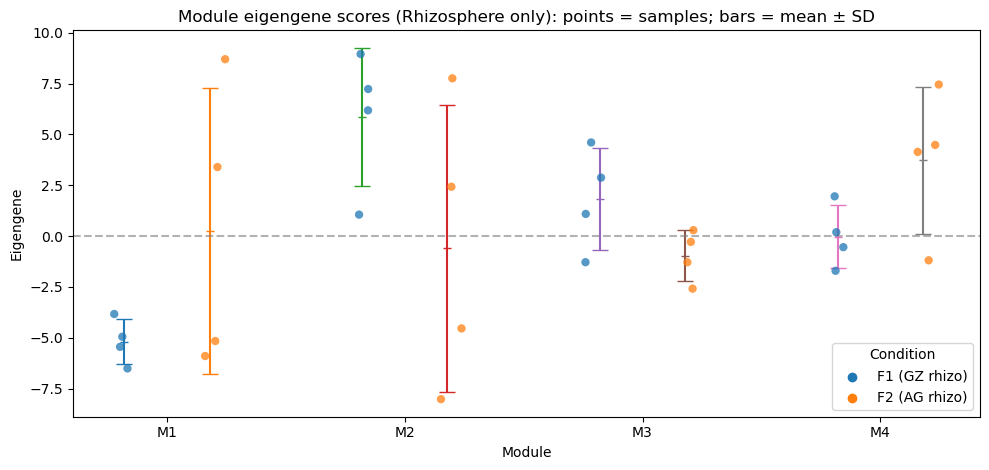

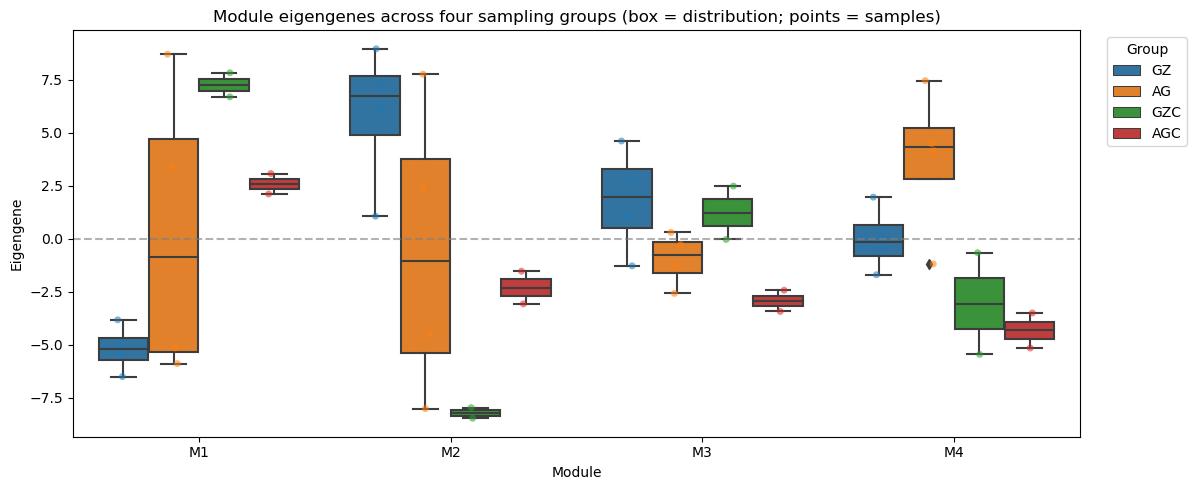

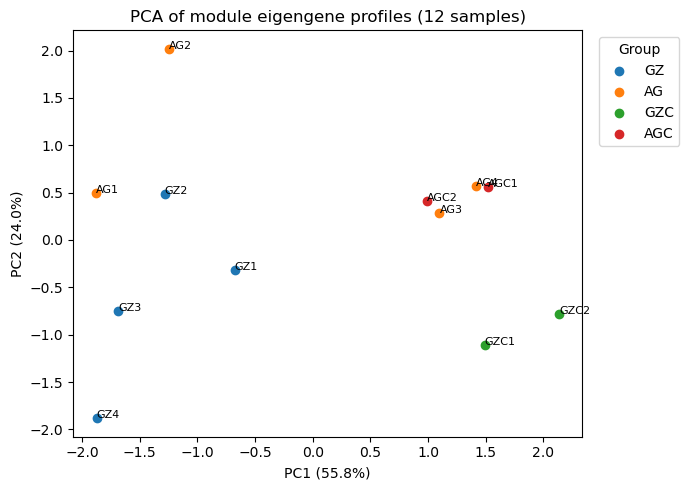

Variable,pH,S (mg/kg),TC (mg/kg),P (mg/kg),K (mg/kg),N–NO3(mg/kg),N–NH4(mg/kg),OC (%),OM (%)
M1,-0.230769,0.187152,-0.021016,-0.251748,-0.262697,-0.280211,0.272727,-0.249124,-0.010508
M2,0.160839,-0.241738,-0.038529,0.314685,0.168126,0.231174,-0.307692,0.196492,-0.031524
M3,0.615385,0.389900,0.665500,0.489510,0.595447,0.458845,-0.398601,0.603512,0.518390
M4,-0.153846,0.062384,-0.136603,0.412587,0.045534,-0.189142,0.440559,0.164913,-0.084063


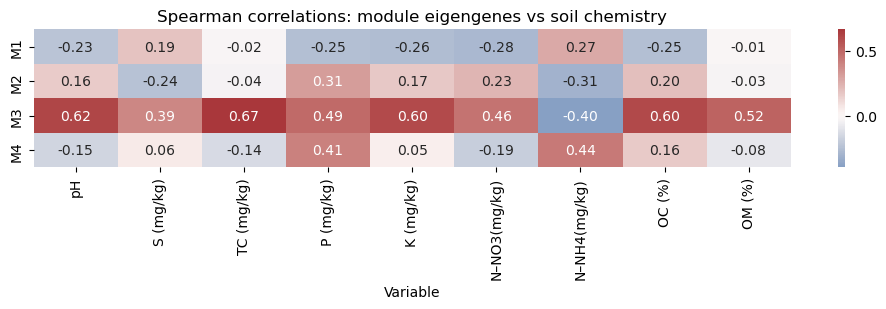

phylum,Acidobacteria,Actinobacteria,Aquificae,Ascomycota,Bacillariophyta,Bacteroidetes,Basidiomycota,Chlamydiae,Chlorobi,Chloroflexi,...,Proteobacteria,Spirochaetes,Streptophyta,Synergistetes,Tenericutes,Thaumarchaeota,Thermotogae,Verrucomicrobia,unclassified (derived from Bacteria),unclassified (derived from unclassified sequences)
Module_ID,,,,,,,,,,,,,,,,,,,,,
1,1.980198,42.574257,0.000000,0.000000,0.000000,5.940594,0.000000,2.970297,0.990099,5.940594,...,17.821782,0.990099,0.990099,0.000000,0.000000,0.000000,0.000000,0.000000,0.990099,0.000000
2,0.000000,20.512821,0.512821,0.512821,0.512821,9.743590,0.512821,0.512821,0.512821,1.025641,...,30.256410,0.512821,1.538462,0.512821,1.538462,0.000000,1.025641,2.564103,0.000000,0.512821
3,7.692308,23.076923,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,30.769231,0.000000,0.000000,0.000000,0.000000,7.692308,0.000000,7.692308,7.692308,0.000000
4,0.000000,48.837209,0.000000,0.000000,0.000000,9.302326,0.000000,0.000000,0.000000,2.325581,...,30.232558,0.000000,0.000000,0.000000,0.000000,0.000000,2.325581,4.651163,0.000000,0.000000


<Figure size 1000x500 with 0 Axes>

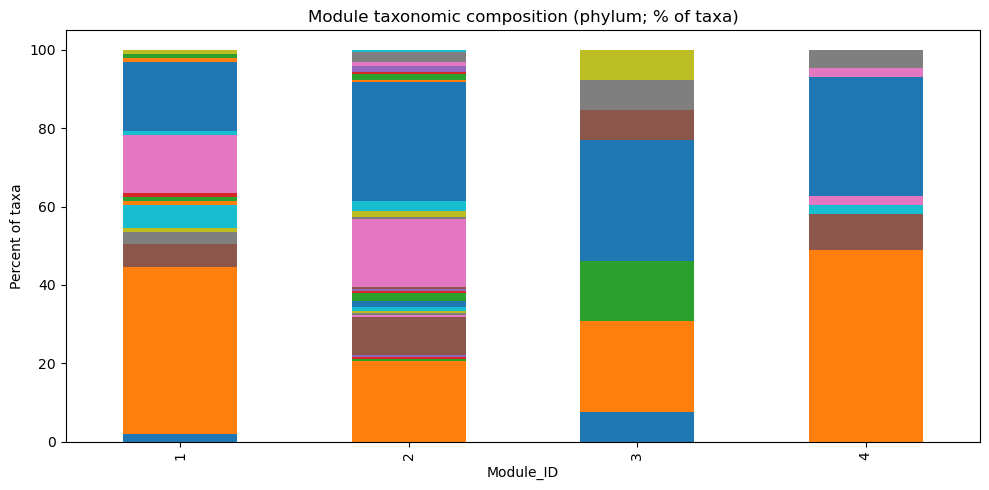

,Module_ID,node_id,genus,phylum,degree
0,1,39,Bacillus,Firmicutes,21
1,1,97,Dehalococcoides,Chloroflexi,19
2,1,336,unclassified (derived from Ktedonobacteria),Chloroflexi,19
3,1,236,Pseudonocardia,Actinobacteria,18
4,1,11,Actinocorallia,Actinobacteria,17
5,1,161,Ktedonobacter,Chloroflexi,17
6,1,23,Alicyclobacillus,Firmicutes,14
7,1,216,Paenibacillus,Firmicutes,14
8,1,145,Herbaspirillum,Proteobacteria,13
9,1,151,Isosphaera,Planctomycetes,13


In [56]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.utils import resample
from scipy.stats import spearmanr, mannwhitneyu, kruskal
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load data
path="/Users/kayadetunji/Documents/DM_work/raw data_taxonomy_CFC.xlsx"
tax_df = pd.read_excel(path, sheet_name="taxonomy")
chem_df = pd.read_excel(path, sheet_name="properties")

# Sample design
gz_rhizo = ['GZ1','GZ2','GZ3','GZ4']
ag_rhizo = ['AG1','AG2','AG3','AG4']
gz_bulk  = ['GZC1','GZC2']
ag_bulk  = ['AGC1','AGC2']
all_samples = gz_rhizo + ag_rhizo + gz_bulk + ag_bulk

# Metadata
meta = pd.DataFrame({'Sample': all_samples})
meta['Field'] = meta['Sample'].str.extract(r'^(GZ|AG)')[0].map({'GZ':'F1_former_grassland', 'AG':'F2_intensive'})
meta['Habitat'] = np.where(meta['Sample'].str.contains('C'), 'Bulk', 'Rhizosphere')
meta['Group'] = meta['Sample'].str.extract(r'^(GZC|AGC|GZ|AG)')[0]
meta = meta.set_index('Sample')
display(meta.reset_index())

# Preprocess
counts = tax_df[all_samples]
mask = (counts > 0).sum(axis=1) >= 3
df_clean = tax_df.loc[mask].reset_index(drop=True)

def clr_transform(count_df: pd.DataFrame) -> pd.DataFrame:
    df_log = np.log(count_df + 1)
    return df_log.sub(df_log.mean(axis=1), axis=0)

df_clr = clr_transform(df_clean[all_samples].T)  # rows=samples, cols=taxa

# Robust network + modules
n_boot = 200
threshold_rho = 0.6
consensus = np.zeros((df_clr.shape[1], df_clr.shape[1]), dtype=float)
for i in range(n_boot):
    rs = resample(df_clr, replace=True, random_state=i)
    corr, _ = spearmanr(rs, axis=0)
    corr = np.nan_to_num(corr)
    consensus += (corr >= threshold_rho).astype(int)

edge_freq = consensus / n_boot
final_adj = (edge_freq >= 0.7).astype(int)
np.fill_diagonal(final_adj, 0)

dist = np.clip(1 - edge_freq, 0, 1)
Z = linkage(squareform(dist, checks=False), method="average")
cluster_labels = fcluster(Z, t=4, criterion="maxclust")
df_clean["Module_ID"] = cluster_labels
unique_modules = sorted(df_clean["Module_ID"].unique())

G = nx.from_numpy_array(final_adj)
G.remove_edges_from(nx.selfloop_edges(G))

# Eigengenes
pca1 = PCA(n_components=1)
eigengenes = pd.DataFrame(index=all_samples)
for m in unique_modules:
    idx = np.where(cluster_labels == m)[0]
    X = df_clr.iloc[:, idx]
    Xs = StandardScaler().fit_transform(X)
    eigengenes[f"M{m}"] = pca1.fit_transform(Xs).flatten()
eigengenes = eigengenes.join(meta)
display(eigengenes.reset_index().rename(columns={'index':'Sample'}))

# Stats helpers
def mwu_effects(x, y):
    U, p = mannwhitneyu(x, y, alternative='two-sided')
    delta = y.mean() - x.mean()
    pooled_sd = np.sqrt((x.var(ddof=1)+y.var(ddof=1))/2)
    d = delta/pooled_sd if pooled_sd>0 else np.nan
    rbc = 1 - (2*U)/(len(x)*len(y))
    return U, p, delta, d, rbc

rows=[]
# A) Field effect within Rhizosphere (F2-F1)
rh = eigengenes[eigengenes['Habitat']=='Rhizosphere']
for m in unique_modules:
    x = rh[rh['Field']=='F1_former_grassland'][f"M{m}"].astype(float)
    y = rh[rh['Field']=='F2_intensive'][f"M{m}"].astype(float)
    U,p,delta,d,rbc = mwu_effects(x,y)
    rows.append([f"M{m}","Field (F2-F1) within Rhizosphere", x.mean(), y.mean(), delta, d, rbc, p, len(x), len(y)])

# B) Habitat effect within each field (Bulk-Rhizo)
for fld in ['F1_former_grassland','F2_intensive']:
    sub = eigengenes[eigengenes['Field']==fld]
    for m in unique_modules:
        x = sub[sub['Habitat']=='Rhizosphere'][f"M{m}"].astype(float)
        y = sub[sub['Habitat']=='Bulk'][f"M{m}"].astype(float)
        if len(x)>0 and len(y)>0:
            U,p,delta,d,rbc = mwu_effects(x,y)
            rows.append([f"M{m}",f"Habitat (Bulk-Rhizo) within {fld}", x.mean(), y.mean(), delta, d, rbc, p, len(x), len(y)])

pairwise_stats = pd.DataFrame(rows, columns=[
    "Module","Contrast","Mean_group1","Mean_group2","Delta(group2-group1)","Cohen_d","Rank_biserial","p_MWU","n1","n2"
]).sort_values(["Contrast","p_MWU"])
display(pairwise_stats)

# C) Kruskal-Wallis across 4 groups
kw_rows=[]
for m in unique_modules:
    groups=[]
    for g in ['GZ','AG','GZC','AGC']:
        groups.append(eigengenes[eigengenes['Group']==g][f"M{m}"].astype(float).values)
    H, p = kruskal(*groups)
    kw_rows.append([f"M{m}", H, p] + [np.mean(groups[i]) for i in range(4)] + [len(groups[i]) for i in range(4)])
kw_df = pd.DataFrame(kw_rows, columns=["Module","Kruskal_H","p_KW","Mean_GZ","Mean_AG","Mean_GZC","Mean_AGC","n_GZ","n_AG","n_GZC","n_AGC"]).sort_values("p_KW")
display(kw_df)

# Long format for plotting
long_df = eigengenes[[f"M{m}" for m in unique_modules] + ['Field','Habitat','Group']].copy()
long_df['Sample'] = long_df.index
long_df = long_df.melt(id_vars=['Sample','Field','Habitat','Group'], var_name='Module', value_name='Eigengene')

# (i) Bar+points like uploaded figure (Rhizosphere only; Field contrast)
rh_long = long_df[long_df['Habitat']=='Rhizosphere'].copy()
rh_long['Condition'] = rh_long['Field'].map({'F1_former_grassland':'F1 (GZ rhizo)','F2_intensive':'F2 (AG rhizo)'})

plt.figure(figsize=(10,4.8))
sns.stripplot(data=rh_long, x='Module', y='Eigengene', hue='Condition', dodge=True, alpha=0.75, size=6)
summary = rh_long.groupby(['Module','Condition'])['Eigengene'].agg(['mean','std']).reset_index()

x_positions = {m:i for i,m in enumerate(sorted(rh_long['Module'].unique()))}
conds = list(summary['Condition'].unique())
cond_offsets = {conds[0]:-0.18, conds[1]:0.18} if len(conds)==2 else {c:0.0 for c in conds}

for _, r in summary.iterrows():
    x = x_positions[r['Module']] + cond_offsets[r['Condition']]
    plt.errorbar(x, r['mean'], yerr=r['std'], fmt='_', capsize=6)

plt.axhline(0, ls='--', c='grey', alpha=0.6)
plt.title("Module eigengene scores (Rhizosphere only): points = samples; bars = mean ± SD")
plt.ylabel("Eigengene")
plt.xlabel("Module")
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Condition")
plt.tight_layout()
plt.show()

# (ii) Box+points across four groups (paper design)
plt.figure(figsize=(11,5))
sns.boxplot(data=long_df, x='Module', y='Eigengene', hue='Group')
sns.stripplot(data=long_df, x='Module', y='Eigengene', hue='Group', dodge=True, alpha=0.55)
plt.axhline(0, ls='--', c='grey', alpha=0.6)
plt.title("Module eigengenes across four sampling groups (box = distribution; points = samples)")
plt.ylabel("Eigengene")
plt.tight_layout()
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:4], labels[:4], title="Group", bbox_to_anchor=(1.02,1), loc="upper left")
plt.show()

# (iii) PCA across all 12 samples using module eigengene profiles
X = eigengenes[[f"M{m}" for m in unique_modules]].values
Xz = StandardScaler().fit_transform(X)
pca2 = PCA(n_components=2)
PC = pca2.fit_transform(Xz)
pca_df = pd.DataFrame(PC, columns=['PC1','PC2'], index=all_samples).join(meta)

plt.figure(figsize=(7,5))
for grp in ['GZ','AG','GZC','AGC']:
    sub = pca_df[pca_df['Group']==grp]
    plt.scatter(sub['PC1'], sub['PC2'], label=grp)
for s in pca_df.index:
    plt.text(pca_df.loc[s,'PC1'], pca_df.loc[s,'PC2'], s, fontsize=8)
plt.title("PCA of module eigengene profiles (12 samples)")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title="Group", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

# (iv) Eigengene–chemistry heatmap
chem = chem_df[['Variable'] + all_samples].set_index('Variable').T
corr_mat = pd.DataFrame(index=[f"M{m}" for m in unique_modules], columns=chem.columns, dtype=float)
for m in unique_modules:
    for var in chem.columns:
        rho, p = spearmanr(eigengenes[f"M{m}"], chem[var])
        corr_mat.loc[f"M{m}", var] = rho
display(corr_mat)

plt.figure(figsize=(10,3.2))
sns.heatmap(corr_mat.astype(float), annot=True, fmt=".2f", center=0, cmap="vlag")
plt.title("Spearman correlations: module eigengenes vs soil chemistry")
plt.tight_layout()
plt.show()

# -----------------------------
# Module drilldown
# -----------------------------
# Module composition by phylum (% taxa)
mod_comp = pd.crosstab(df_clean['Module_ID'], df_clean['phylum'])
mod_comp_pct = mod_comp.div(mod_comp.sum(axis=1), axis=0) * 100
display(mod_comp_pct)

plt.figure(figsize=(10,5))
mod_comp_pct.plot(kind='bar', stacked=True, figsize=(10,5), legend=False)
plt.title("Module taxonomic composition (phylum; % of taxa)")
plt.ylabel("Percent of taxa")
plt.xlabel("Module_ID")
plt.tight_layout()
plt.show()

# Top taxa by degree within each module
deg = dict(G.degree())
top_by_module=[]
for m in unique_modules:
    nodes_m = [i for i in G.nodes() if df_clean.loc[i,'Module_ID']==m]
    sub_deg = sorted([(i, deg.get(i,0)) for i in nodes_m], key=lambda x:x[1], reverse=True)[:10]
    for node_id, dval in sub_deg:
        top_by_module.append([m, node_id, df_clean.loc[node_id,'genus'], df_clean.loc[node_id,'phylum'], dval])
top_by_module_df = pd.DataFrame(top_by_module, columns=['Module_ID','node_id','genus','phylum','degree']).sort_values(['Module_ID','degree'], ascending=[True,False])
display(top_by_module_df)


,Module,n_taxa,n_edges_within,density_within,n_connected_components,largest_component_size,isolates_in_module
0,M4,43,56,0.062016,11,27,7


,node_id,genus,phylum,Module_ID
3,3,Acidimicrobium,Actinobacteria,4
15,15,Actinoplanes,Actinobacteria,4
21,21,Agromyces,Actinobacteria,4
33,33,Arcanobacterium,Actinobacteria,4
72,72,Cellulosimicrobium,Actinobacteria,4
90,90,Couchioplanes,Actinobacteria,4
140,140,Gordonia,Actinobacteria,4
141,141,Gordonibacter,Actinobacteria,4
149,149,Intrasporangium,Actinobacteria,4
155,155,Kineococcus,Actinobacteria,4


,phylum,n_taxa,pct
0,Actinobacteria,21,48.837209
1,Proteobacteria,13,30.232558
2,Bacteroidetes,4,9.302326
3,Verrucomicrobia,2,4.651163
4,Chloroflexi,1,2.325581
5,Firmicutes,1,2.325581
6,Thermotogae,1,2.325581


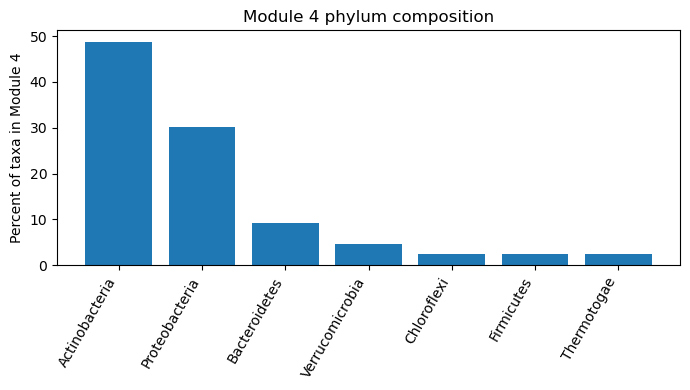

,node_id,genus,phylum,degree_within_M4,betweenness_within_M4,eigenvector_within_M4,clustering_within_M4,degree_global,eigenvector_global
2,132,Geoalkalibacter,Proteobacteria,8,0.136643,4.489601e-01,0.464286,8,2.171825e-04
16,181,Mesorhizobium,Proteobacteria,7,0.032288,3.760194e-01,0.428571,7,1.765487e-04
42,121,Fervidobacterium,Thermotogae,6,0.026655,3.939314e-01,0.733333,10,5.832232e-04
36,249,Roseiflexus,Chloroflexi,6,0.053426,2.276172e-02,0.400000,11,1.238452e-02
28,80,Chondromyces,Proteobacteria,5,0.000523,3.575301e-01,0.900000,6,1.569552e-03
7,21,Agromyces,Actinobacteria,5,0.000523,3.575301e-01,0.900000,9,4.144206e-04
14,33,Arcanobacterium,Actinobacteria,5,0.011614,3.346720e-01,0.800000,9,5.480847e-04
10,282,Streptococcus,Firmicutes,5,0.082462,1.756032e-01,0.200000,5,2.472499e-05
21,314,Tsukamurella,Actinobacteria,5,0.210221,5.708478e-02,0.300000,5,1.237108e-03
17,182,Methylacidiphilum,Verrucomicrobia,5,0.126597,2.171736e-02,0.500000,6,4.669228e-03


,node_id,genus,phylum,degree_within_M4,betweenness_within_M4,eigenvector_within_M4,clustering_within_M4,degree_global,eigenvector_global
2,132,Geoalkalibacter,Proteobacteria,8,0.136643,0.448960,0.464286,8,0.000217
16,181,Mesorhizobium,Proteobacteria,7,0.032288,0.376019,0.428571,7,0.000177
42,121,Fervidobacterium,Thermotogae,6,0.026655,0.393931,0.733333,10,0.000583
36,249,Roseiflexus,Chloroflexi,6,0.053426,0.022762,0.400000,11,0.012385
28,80,Chondromyces,Proteobacteria,5,0.000523,0.357530,0.900000,6,0.001570
7,21,Agromyces,Actinobacteria,5,0.000523,0.357530,0.900000,9,0.000414
14,33,Arcanobacterium,Actinobacteria,5,0.011614,0.334672,0.800000,9,0.000548
10,282,Streptococcus,Firmicutes,5,0.082462,0.175603,0.200000,5,0.000025
21,314,Tsukamurella,Actinobacteria,5,0.210221,0.057085,0.300000,5,0.001237
17,182,Methylacidiphilum,Verrucomicrobia,5,0.126597,0.021717,0.500000,6,0.004669


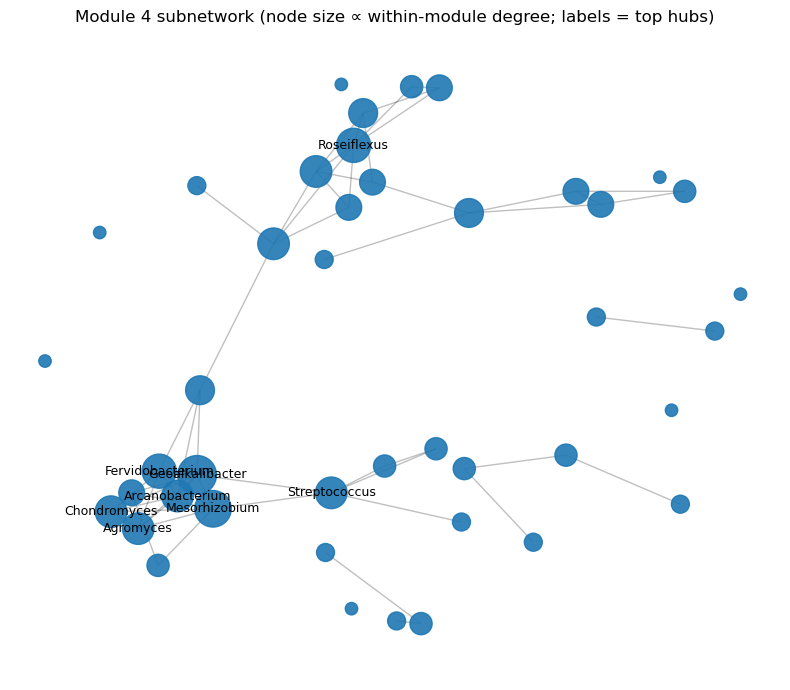

,Sample,M4,Group,Field,Habitat
0,GZ1,0.191797,GZ,F1_former_grassland,Rhizosphere
1,GZ2,-0.542843,GZ,F1_former_grassland,Rhizosphere
2,GZ3,1.956140,GZ,F1_former_grassland,Rhizosphere
3,GZ4,-1.704429,GZ,F1_former_grassland,Rhizosphere
4,AG1,4.141855,AG,F2_intensive,Rhizosphere
5,AG2,7.454018,AG,F2_intensive,Rhizosphere
6,AG3,-1.190845,AG,F2_intensive,Rhizosphere
7,AG4,4.484320,AG,F2_intensive,Rhizosphere
8,GZC1,-0.661512,GZC,F1_former_grassland,Bulk
9,GZC2,-5.460549,GZC,F1_former_grassland,Bulk


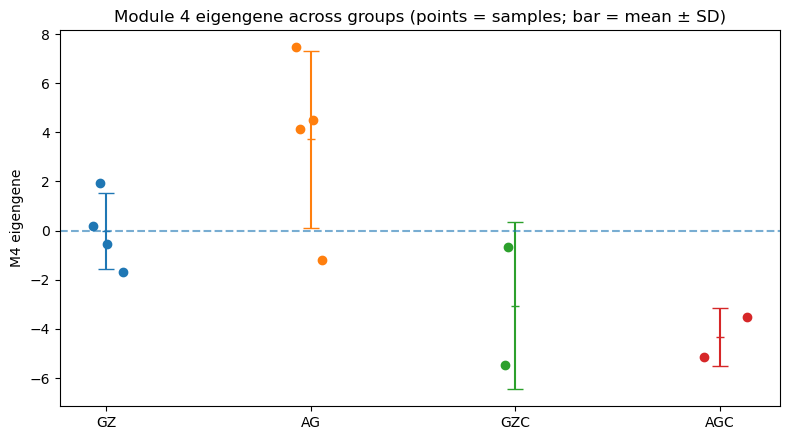

,Soil_variable,Spearman_rho,p,Abs_rho
6,N–NH4(mg/kg),0.440559,0.151735,0.440559
3,P (mg/kg),0.412587,0.182564,0.412587
5,N–NO3(mg/kg),-0.189142,0.556033,0.189142
7,OC (%),0.164913,0.608520,0.164913
0,pH,-0.153846,0.633091,0.153846
2,TC (mg/kg),-0.136603,0.672054,0.136603
8,OM (%),-0.084063,0.795063,0.084063
1,S (mg/kg),0.062384,0.847271,0.062384
4,K (mg/kg),0.045534,0.888252,0.045534


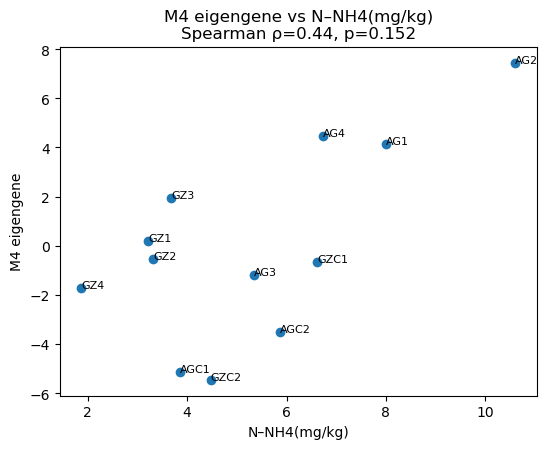

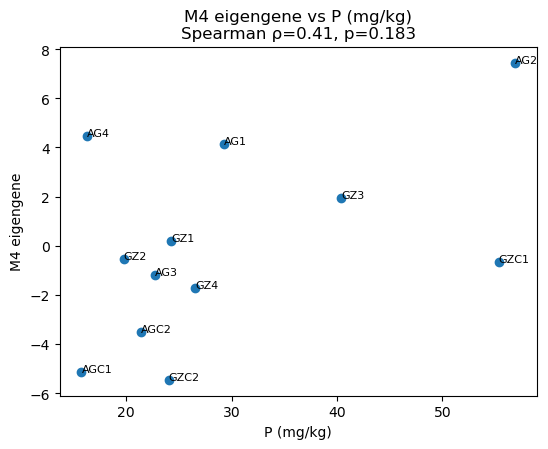

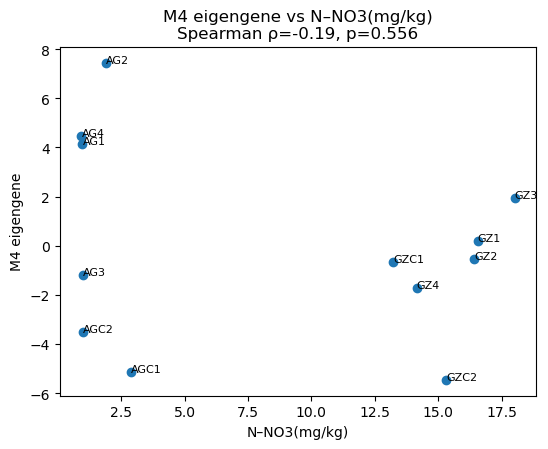

In [60]:
# -----------------------------
# MODULE 4 DRILLDOWN
# -----------------------------
target_module = 4

mod4_nodes = [n for n in G.nodes() if df_clean.loc[n, 'Module_ID'] == target_module]
G4 = G.subgraph(mod4_nodes).copy()

mod4_summary = pd.DataFrame([{
    "Module": f"M{target_module}",
    "n_taxa": len(mod4_nodes),
    "n_edges_within": G4.number_of_edges(),
    "density_within": nx.density(G4) if len(mod4_nodes)>1 else 0.0,
    "n_connected_components": nx.number_connected_components(G4) if len(mod4_nodes)>0 else 0,
    "largest_component_size": len(max(nx.connected_components(G4), key=len)) if G4.number_of_edges()>0 else (len(mod4_nodes) if len(mod4_nodes)>0 else 0),
    "isolates_in_module": sum(1 for n in G4.nodes() if G4.degree(n)==0)
}])
display(mod4_summary)

# Taxa membership
mod4_taxa = df_clean.loc[mod4_nodes, ['genus','phylum','Module_ID']].copy()
mod4_taxa['node_id'] = mod4_taxa.index
mod4_taxa = mod4_taxa[['node_id','genus','phylum','Module_ID']].sort_values(['phylum','genus'])
display(mod4_taxa)

# Phylum composition
mod4_comp = mod4_taxa['phylum'].value_counts().rename_axis('phylum').reset_index(name='n_taxa')
mod4_comp['pct'] = 100 * mod4_comp['n_taxa'] / mod4_comp['n_taxa'].sum()
display(mod4_comp)

plt.figure(figsize=(7,4))
plt.bar(mod4_comp['phylum'], mod4_comp['pct'])
plt.xticks(rotation=60, ha='right')
plt.ylabel("Percent of taxa in Module 4")
plt.title("Module 4 phylum composition")
plt.tight_layout()
plt.show()

# Within-module hub metrics
deg_within = dict(G4.degree())
bet_within = nx.betweenness_centrality(G4, normalized=True) if G4.number_of_edges()>0 else {n:0.0 for n in G4.nodes()}
eig_within = nx.eigenvector_centrality_numpy(G4) if G4.number_of_edges()>0 and G4.number_of_nodes()>1 else {n:0.0 for n in G4.nodes()}
clust_within = nx.clustering(G4) if G4.number_of_edges()>0 else {n:0.0 for n in G4.nodes()}

# Global metrics for context
deg_global = dict(G.degree())
eig_global = nx.eigenvector_centrality_numpy(G)

mod4_metrics = pd.DataFrame({
    "node_id": list(G4.nodes()),
    "genus": [df_clean.loc[n,'genus'] for n in G4.nodes()],
    "phylum": [df_clean.loc[n,'phylum'] for n in G4.nodes()],
    "degree_within_M4": [deg_within[n] for n in G4.nodes()],
    "betweenness_within_M4": [bet_within.get(n,0.0) for n in G4.nodes()],
    "eigenvector_within_M4": [eig_within.get(n,0.0) for n in G4.nodes()],
    "clustering_within_M4": [clust_within.get(n,0.0) for n in G4.nodes()],
    "degree_global": [deg_global.get(n,0) for n in G4.nodes()],
    "eigenvector_global": [eig_global.get(n,0.0) for n in G4.nodes()],
}).sort_values(["degree_within_M4","eigenvector_within_M4"], ascending=False)

display(mod4_metrics)

top_hubs_m4 = mod4_metrics.head(12)
display(top_hubs_m4)

# Plot Module 4 subnetwork (size by within-degree; label top hubs)
plt.figure(figsize=(8,7))
pos4 = nx.spring_layout(G4, seed=42, k=0.45)

sizes = np.array([deg_within[n] for n in G4.nodes()], dtype=float)
sizes = 80 + (sizes / max(sizes.max(),1)) * 700

nx.draw_networkx_edges(G4, pos4, alpha=0.25)
nx.draw_networkx_nodes(G4, pos4, node_size=sizes, alpha=0.9)

hub_nodes = top_hubs_m4['node_id'].head(8).tolist()
labels = {n: df_clean.loc[n,'genus'] for n in hub_nodes}
nx.draw_networkx_labels(G4, pos4, labels=labels, font_size=9)

plt.title("Module 4 subnetwork (node size ∝ within-module degree; labels = top hubs)")
plt.axis('off')
plt.tight_layout()
plt.show()

# Module 4 eigengene across groups
m4_scores = eigengenes[[f"M{target_module}",'Group','Field','Habitat']].copy()
display(m4_scores.reset_index().rename(columns={'index':'Sample'}))

order = ['GZ','AG','GZC','AGC']
vals = [m4_scores[m4_scores['Group']==g][f"M{target_module}"].astype(float).values for g in order]
means = [np.mean(v) for v in vals]
sds = [np.std(v, ddof=1) if len(v)>1 else 0.0 for v in vals]

plt.figure(figsize=(8,4.5))
for i,g in enumerate(order):
    y = vals[i]
    x = np.random.normal(loc=i, scale=0.06, size=len(y))
    plt.scatter(x, y)
for i in range(len(order)):
    plt.errorbar(i, means[i], yerr=sds[i], fmt='_', capsize=6)
plt.axhline(0, ls='--', alpha=0.6)
plt.xticks(range(len(order)), order)
plt.ylabel("M4 eigengene")
plt.title("Module 4 eigengene across groups (points = samples; bar = mean ± SD)")
plt.tight_layout()
plt.show()

# Chemistry associations for Module 4: rank by |rho|
chem = chem_df[['Variable'] + all_samples].set_index('Variable').T
m4_corr_rows=[]
for var in chem.columns:
    rho, p = spearmanr(eigengenes[f"M{target_module}"], chem[var])
    m4_corr_rows.append([var, rho, p, abs(rho)])
m4_corr = pd.DataFrame(m4_corr_rows, columns=['Soil_variable','Spearman_rho','p','Abs_rho']).sort_values('Abs_rho', ascending=False)
display(m4_corr)

top_vars = m4_corr.head(3)['Soil_variable'].tolist()

# Scatter plots for top 3 chemistry variables
for var in top_vars:
    x = chem[var].astype(float).values
    y = eigengenes[f"M{target_module}"].astype(float).values
    rho = float(m4_corr.loc[m4_corr['Soil_variable']==var,'Spearman_rho'].iloc[0])
    pval = float(m4_corr.loc[m4_corr['Soil_variable']==var,'p'].iloc[0])

    plt.figure(figsize=(5.6,4.6))
    plt.scatter(x, y)
    for i,s in enumerate(all_samples):
        plt.text(x[i], y[i], s, fontsize=8)
    plt.xlabel(var)
    plt.ylabel("M4 eigengene")
    plt.title(f"M4 eigengene vs {var}\nSpearman ρ={rho:.2f}, p={pval:.3f}")
    plt.tight_layout()
    plt.show()



ALPHA DIVERSITY SUMMARY (GZ vs AG):
         Metric Reference (GZ) mean ± SD Degraded (AG) mean ± SD  t-test p  Wilcoxon p
       Richness           241.17 ± 26.60          228.17 ± 48.74  0.582600    0.809855
        Shannon              3.77 ± 0.13             3.91 ± 0.16  0.117811    0.132035
  Simpson (1-D)              0.90 ± 0.03             0.92 ± 0.03  0.138819    0.132035
     InvSimpson             10.19 ± 2.81            13.60 ± 4.02  0.123045    0.132035
Pielou_evenness              0.69 ± 0.02             0.72 ± 0.04  0.071097    0.093074


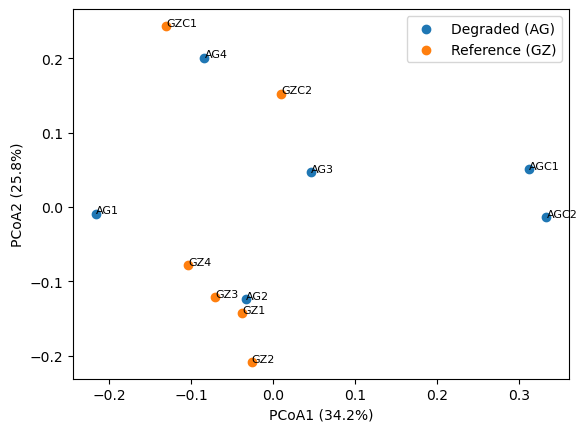


PERMANOVA (Bray-Curtis) GZ vs AG:
{'F': 1.1441183510549835, 'p': 0.364, 'R2': 0.1026656676655514, 'df_between': 1, 'df_within': 10, 'permutations': 999}


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
path = "/Users/kayadetunji/Downloads/soil MB/raw data_taxonomy_CFC.xlsx"
tax_df = pd.read_excel(path, sheet_name="taxonomy")

# Identify sample columns (everything except taxonomy descriptors)
meta_cols = ["domain", "phylum", "className", "order", "family", "genus"]
sample_cols = [c for c in tax_df.columns if c not in meta_cols]

# Community matrix: samples x taxa (rows=samples, cols=taxa)
community = tax_df[sample_cols].fillna(0).astype(float).T
community.index.name = "Sample"

# Group labels based on sample name prefix
groups = pd.Series(
    ["Reference (GZ)" if s.startswith("GZ")
     else "Degraded (AG)" if s.startswith("AG")
     else "Other"
     for s in community.index],
    index=community.index,
    name="Zone"
)

# Keep only GZ/AG samples
keep = groups.isin(["Reference (GZ)", "Degraded (AG)"])
community = community.loc[keep]
groups = groups.loc[keep]

# -----------------------------
# Alpha diversity metrics
# -----------------------------
def richness(counts):
    counts = np.asarray(counts, dtype=float)
    return int((counts > 0).sum())

def shannon(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total <= 0:
        return 0.0
    p = counts[counts > 0] / total
    return -(p * np.log(p)).sum()

def simpson_1_minus_D(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total <= 0:
        return 0.0
    p = counts[counts > 0] / total
    return 1.0 - (p**2).sum()

def inverse_simpson(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total <= 0:
        return 0.0
    p = counts[counts > 0] / total
    denom = (p**2).sum()
    return 1.0 / denom if denom > 0 else 0.0

def pielou_evenness(counts):
    S = richness(counts)
    if S <= 1:
        return 0.0
    H = shannon(counts)
    return H / np.log(S)

alpha = pd.DataFrame({
    "Richness": community.apply(richness, axis=1),
    "Shannon": community.apply(shannon, axis=1),
    "Simpson (1-D)": community.apply(simpson_1_minus_D, axis=1),
    "InvSimpson": community.apply(inverse_simpson, axis=1),
    "Pielou_evenness": community.apply(pielou_evenness, axis=1),
})
alpha["Zone"] = groups

def mean_sd(x):
    return f"{x.mean():.2f} ± {x.std(ddof=1):.2f}"

metrics = ["Richness", "Shannon", "Simpson (1-D)", "InvSimpson", "Pielou_evenness"]
alpha_rows = []

for m in metrics:
    gz = alpha.loc[alpha["Zone"] == "Reference (GZ)", m].astype(float)
    ag = alpha.loc[alpha["Zone"] == "Degraded (AG)", m].astype(float)

    # Welch t-test
    t_p = stats.ttest_ind(gz, ag, equal_var=False, nan_policy="omit").pvalue
    # Mann–Whitney U (often called Wilcoxon rank-sum)
    w_p = stats.mannwhitneyu(gz, ag, alternative="two-sided").pvalue

    alpha_rows.append([m, mean_sd(gz), mean_sd(ag), t_p, w_p])

alpha_table = pd.DataFrame(
    alpha_rows,
    columns=["Metric", "Reference (GZ) mean ± SD", "Degraded (AG) mean ± SD", "t-test p", "Wilcoxon p"]
)

print("\nALPHA DIVERSITY SUMMARY (GZ vs AG):")
print(alpha_table.to_string(index=False))

# -----------------------------
# Beta diversity: Bray-Curtis + PCoA
# -----------------------------
dist_vec = pdist(community.values, metric="braycurtis")
dist_mat = squareform(dist_vec)

def pcoa(distance_matrix, n_components=2):
    D = np.asarray(distance_matrix, dtype=float)
    n = D.shape[0]
    D2 = D**2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    pos = eigvals > 1e-12
    eigvals_pos = eigvals[pos]
    eigvecs_pos = eigvecs[:, pos]
    coords = eigvecs_pos[:, :n_components] * np.sqrt(eigvals_pos[:n_components])
    var_expl = eigvals_pos / eigvals_pos.sum()
    return coords, var_expl

coords, var_expl = pcoa(dist_mat, n_components=2)

pcoa_df = pd.DataFrame(coords, index=community.index, columns=["PCoA1", "PCoA2"])
pcoa_df["Zone"] = groups

# Plot PCoA (matplotlib default colors)
fig = plt.figure()
ax = fig.add_subplot(111)
for zone, sub in pcoa_df.groupby("Zone"):
    ax.scatter(sub["PCoA1"], sub["PCoA2"], label=zone)

for sample, r in pcoa_df.iterrows():
    ax.text(r["PCoA1"], r["PCoA2"], sample, fontsize=8)

ax.set_xlabel(f"PCoA1 ({var_expl[0]*100:.1f}%)")
ax.set_ylabel(f"PCoA2 ({var_expl[1]*100:.1f}%)")
ax.legend()
plt.show()

# -----------------------------
# PERMANOVA (one-factor)
# -----------------------------
def permanova(distance_matrix, grouping, permutations=999, seed=42):
    rng = np.random.default_rng(seed)
    D = np.asarray(distance_matrix, dtype=float)
    n = D.shape[0]

    # Gower-centered matrix
    D2 = D**2
    J = np.eye(n) - np.ones((n, n)) / n
    A = -0.5 * J @ D2 @ J

    SST = np.trace(A)

    groups_arr = np.asarray(grouping)
    levels = pd.unique(groups_arr)

    # Dummy design matrix (n x k)
    X = np.column_stack([(groups_arr == lev).astype(float) for lev in levels])
    XtX_inv = np.linalg.pinv(X.T @ X)
    H = X @ XtX_inv @ X.T

    SSB = np.trace(H @ A)
    SSW = SST - SSB

    dfb = len(levels) - 1
    dfw = n - len(levels)

    F_obs = (SSB / dfb) / (SSW / dfw)
    R2 = SSB / SST

    perm_F = np.empty(permutations)
    for i in range(permutations):
        perm = rng.permutation(n)
        Xp = X[perm, :]
        Hp = Xp @ XtX_inv @ Xp.T
        SSBp = np.trace(Hp @ A)
        SSWp = SST - SSBp
        perm_F[i] = (SSBp / dfb) / (SSWp / dfw)

    p_value = (np.sum(perm_F >= F_obs) + 1) / (permutations + 1)

    return {"F": F_obs, "p": p_value, "R2": R2, "df_between": dfb, "df_within": dfw, "permutations": permutations}

permanova_res = permanova(dist_mat, groups.values, permutations=999, seed=42)

print("\nPERMANOVA (Bray-Curtis) GZ vs AG:")
print(permanova_res)

In [2]:
import numpy as np
import pandas as pd

# -----------------------------
# PERMDISP (distance-based dispersion test)
# -----------------------------
def permdisp(distance_matrix, grouping, permutations=999, seed=42):
    """
    distance_matrix : square (n x n) numpy array
    grouping        : array-like of group labels (length n)
    """
    rng = np.random.default_rng(seed)
    D = np.asarray(distance_matrix, dtype=float)
    groups = np.asarray(grouping)

    n = D.shape[0]
    levels = np.unique(groups)

    # ---- Compute distances to group centroids ----
    dist_to_centroid = np.zeros(n)

    for lev in levels:
        idx = np.where(groups == lev)[0]
        # centroid distance = mean distance to all other points in same group
        subD = D[np.ix_(idx, idx)]
        centroid_dist = subD.mean(axis=1)
        dist_to_centroid[idx] = centroid_dist

    # ---- Observed F-statistic ----
    grand_mean = dist_to_centroid.mean()

    ss_between = sum(
        len(dist_to_centroid[groups == lev]) *
        (dist_to_centroid[groups == lev].mean() - grand_mean) ** 2
        for lev in levels
    )

    ss_within = sum(
        ((dist_to_centroid[groups == lev] -
          dist_to_centroid[groups == lev].mean()) ** 2).sum()
        for lev in levels
    )

    df_between = len(levels) - 1
    df_within = n - len(levels)

    ms_between = ss_between / df_between
    ms_within = ss_within / df_within

    F_obs = ms_between / ms_within

    # ---- Permutation test ----
    perm_F = np.zeros(permutations)

    for i in range(permutations):
        perm_groups = rng.permutation(groups)

        ssb_p = sum(
            len(dist_to_centroid[perm_groups == lev]) *
            (dist_to_centroid[perm_groups == lev].mean() - grand_mean) ** 2
            for lev in levels
        )

        ssw_p = sum(
            ((dist_to_centroid[perm_groups == lev] -
              dist_to_centroid[perm_groups == lev].mean()) ** 2).sum()
            for lev in levels
        )

        perm_F[i] = (ssb_p / df_between) / (ssw_p / df_within)

    p_value = (np.sum(perm_F >= F_obs) + 1) / (permutations + 1)

    return {
        "F": F_obs,
        "p": p_value,
        "df_between": df_between,
        "df_within": df_within,
        "permutations": permutations
    }

# -----------------------------
# Run PERMDISP
# -----------------------------
permdisp_res = permdisp(dist_mat, groups.values, permutations=999, seed=42)

print("\nPERMDISP (Bray–Curtis) – GZ vs AG")
print(permdisp_res)


PERMDISP (Bray–Curtis) – GZ vs AG
{'F': 12.161995235650128, 'p': 0.01, 'df_between': 1, 'df_within': 10, 'permutations': 999}


                count      mean       std       min       25%       50%  \
Zone                                                                      
Degraded (AG)     6.0  0.349484  0.026462  0.311912  0.332168  0.354022   
Reference (GZ)    6.0  0.297612  0.025045  0.269794  0.282173  0.293312   

                     75%       max  
Zone                                
Degraded (AG)   0.365776  0.382372  
Reference (GZ)  0.306384  0.340053  


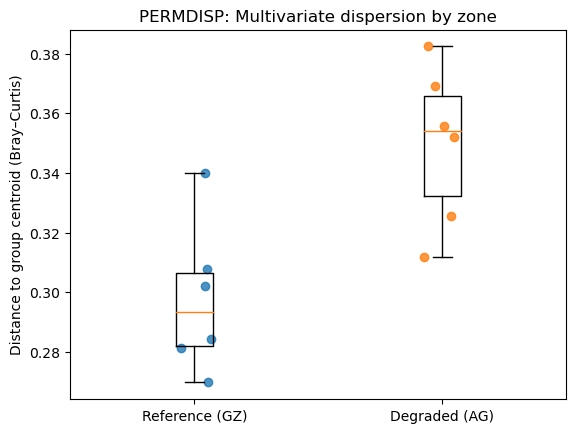

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Compute distances to group centroids (PERMDISP-style)
# -----------------------------
def distances_to_centroid(distance_matrix, grouping):
    """
    Returns a pandas Series of each sample's distance to its group centroid,
    where centroid distance is approximated as the mean distance to all other
    samples in the same group (standard PERMDISP logic on distance matrices).
    """
    D = np.asarray(distance_matrix, dtype=float)
    groups = pd.Series(grouping).reset_index(drop=True)

    n = D.shape[0]
    d2c = np.zeros(n)

    for lev in groups.unique():
        idx = np.where(groups.values == lev)[0]
        subD = D[np.ix_(idx, idx)]
        d2c[idx] = subD.mean(axis=1)

    return pd.Series(d2c, index=np.arange(n), name="Dist_to_centroid")

# If you have a DataFrame distance matrix instead of numpy, convert safely:
# dist_mat = dist_df.values

# Make sure groups is aligned with dist_mat row order.
# Here we assume dist_mat rows/cols correspond to groups.index order used earlier.
d2c = distances_to_centroid(dist_mat, groups.values)

# Build plotting DataFrame with sample names (optional)
plot_df = pd.DataFrame({
    "Sample": groups.index.values if hasattr(groups, "index") else np.arange(len(groups)),
    "Zone": groups.values,
    "Dist_to_centroid": d2c.values
})

print(plot_df.groupby("Zone")["Dist_to_centroid"].describe())

# -----------------------------
# Standard PERMDISP boxplot (+ optional points)
# -----------------------------
zones = plot_df["Zone"].unique()
data = [plot_df.loc[plot_df["Zone"] == z, "Dist_to_centroid"].values for z in zones]

fig = plt.figure()
ax = fig.add_subplot(111)

# Boxplot
ax.boxplot(data, labels=zones)

# Optional: overlay points (jittered)
for i, z in enumerate(zones, start=1):
    y = plot_df.loc[plot_df["Zone"] == z, "Dist_to_centroid"].values
    x = i + (np.random.rand(len(y)) - 0.5) * 0.15  # jitter
    ax.scatter(x, y, alpha=0.8)

ax.set_ylabel("Distance to group centroid (Bray–Curtis)")
ax.set_title("PERMDISP: Multivariate dispersion by zone")
plt.xticks(rotation=0)
plt.show()

In [4]:
import pandas as pd
import numpy as np
from scipy import stats

# -----------------------------
# Load soil chemistry data
# -----------------------------
chem_df = pd.read_excel(
    "/Users/kayadetunji/Downloads/soil MB/raw data_taxonomy_CFC.xlsx",
    sheet_name="physical & chemical properties"
)

# Rhizosphere samples ONLY
gz_cols = ["GZ1", "GZ2", "GZ3", "GZ4"]
ag_cols = ["AG1", "AG2", "AG3", "AG4"]

rows = []

for _, row in chem_df.iterrows():
    gz = row[gz_cols].astype(float)
    ag = row[ag_cols].astype(float)

    rows.append([
        row["Variable"],
        f"{gz.mean():.2f} ± {gz.std(ddof=1):.2f}",
        f"{ag.mean():.2f} ± {ag.std(ddof=1):.2f}",
        stats.mannwhitneyu(gz, ag, alternative="two-sided").pvalue
    ])

soil_table = pd.DataFrame(
    rows,
    columns=[
        "Variable",
        "Reference (GZ) mean ± SD",
        "Degraded (AG) mean ± SD",
        "Wilcoxon p-value"
    ]
)

print("\nTable 1. Soil properties (rhizosphere only)")
print(soil_table.to_string(index=False))


Table 1. Soil properties (rhizosphere only)
    Variable Reference (GZ) mean ± SD Degraded (AG) mean ± SD  Wilcoxon p-value
          pH              6.73 ± 0.25             5.20 ± 0.31          0.028571
   S (mg/kg)              4.75 ± 7.75             0.17 ± 0.34          0.408352
  TC (mg/kg)              1.16 ± 0.09             0.47 ± 0.04          0.029401
   P (mg/kg)             27.74 ± 8.89           31.30 ± 17.87          1.000000
   K (mg/kg)           340.00 ± 71.89          108.28 ± 15.45          0.029401
N–NO3(mg/kg)             16.29 ± 1.59             1.20 ± 0.47          0.028571
N–NH4(mg/kg)              3.02 ± 0.79             7.67 ± 2.24          0.028571
      OC (%)              1.00 ± 0.12             0.26 ± 0.02          0.029401
      OM (%)              3.96 ± 0.34             1.50 ± 0.11          0.028571


Richness: Wilcoxon p = 0.0591


<Figure size 640x480 with 0 Axes>

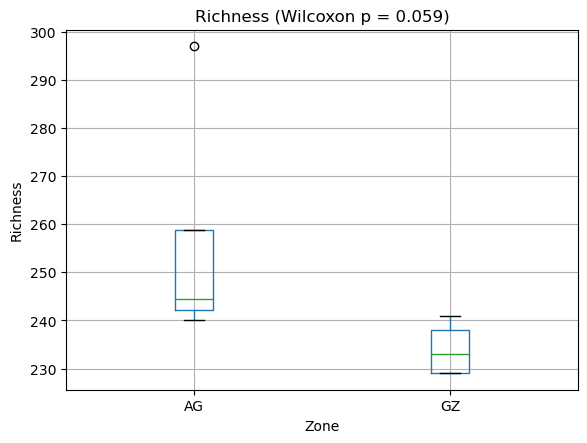

Shannon: Wilcoxon p = 0.1143


<Figure size 640x480 with 0 Axes>

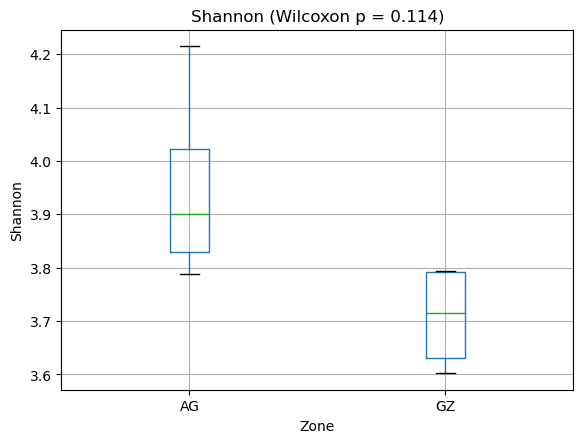

Simpson: Wilcoxon p = 0.1143


<Figure size 640x480 with 0 Axes>

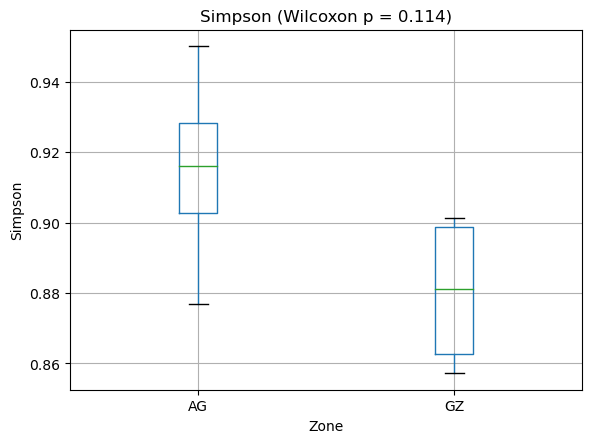

InvSimpson: Wilcoxon p = 0.1143


<Figure size 640x480 with 0 Axes>

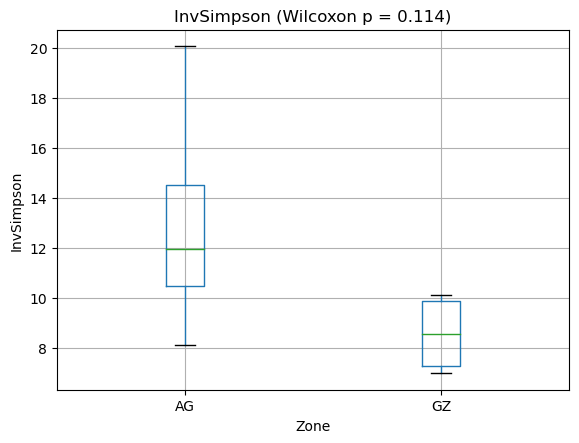

Evenness: Wilcoxon p = 0.2000


<Figure size 640x480 with 0 Axes>

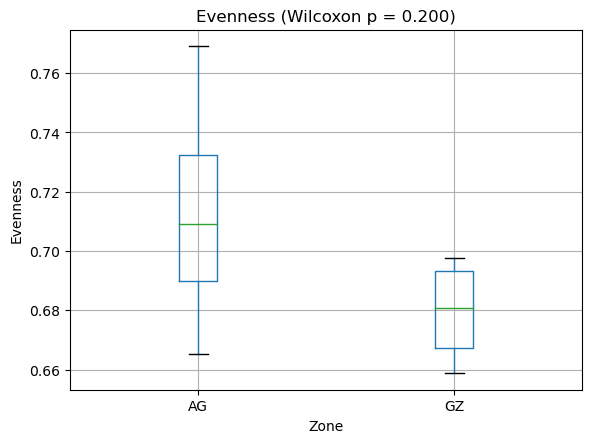

In [6]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------------
# Load taxonomy table
# -----------------------------
tax_df = pd.read_excel(
    "/Users/kayadetunji/Downloads/soil MB/raw data_taxonomy_CFC.xlsx",
    sheet_name="taxonomy"
)

meta_cols = ["domain", "phylum", "className", "order", "family", "genus"]
samples = ["GZ1", "GZ2", "GZ3", "GZ4", "AG1", "AG2", "AG3", "AG4"]

community = tax_df[samples].fillna(0).T
groups = pd.Series(
    ["GZ"]*4 + ["AG"]*4,
    index=community.index,
    name="Zone"
)

# -----------------------------
# Alpha diversity functions
# -----------------------------
def richness(x): return (x > 0).sum()

def shannon(x):
    p = x[x > 0] / x.sum()
    return -(p * np.log(p)).sum()

def simpson(x):
    p = x[x > 0] / x.sum()
    return 1 - (p**2).sum()

def inv_simpson(x):
    p = x[x > 0] / x.sum()
    return 1 / (p**2).sum()

def pielou(x):
    S = richness(x)
    return shannon(x) / np.log(S) if S > 1 else 0

alpha = pd.DataFrame({
    "Richness": community.apply(richness, axis=1),
    "Shannon": community.apply(shannon, axis=1),
    "Simpson": community.apply(simpson, axis=1),
    "InvSimpson": community.apply(inv_simpson, axis=1),
    "Evenness": community.apply(pielou, axis=1),
    "Zone": groups
})

# -----------------------------
# Wilcoxon tests + boxplots
# -----------------------------
for metric in ["Richness", "Shannon", "Simpson", "InvSimpson", "Evenness"]:
    gz = alpha.loc[alpha.Zone=="GZ", metric]
    ag = alpha.loc[alpha.Zone=="AG", metric]

    p = stats.mannwhitneyu(gz, ag, alternative="two-sided").pvalue
    print(f"{metric}: Wilcoxon p = {p:.4f}")

    plt.figure()
    alpha.boxplot(column=metric, by="Zone")
    plt.title(f"{metric} (Wilcoxon p = {p:.3f})")
    plt.suptitle("")
    plt.ylabel(metric)
    plt.show()

    # plt.figure()
    # alpha.boxplot(column=metric, by="Zone", rot=90)
    # plt.title(f"{metric} (Wilcoxon p = {p:.3f})")
    # plt.suptitle("")
    # plt.xlabel(metric)
    # plt.show()

In [8]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# -------------------------------------------------
# Bray–Curtis distance matrix (rhizosphere only)
# -------------------------------------------------
dist = squareform(pdist(community.values, metric="braycurtis"))

# -------------------------------------------------
# PERMDISP function
# -------------------------------------------------
def permdisp(distance_matrix, grouping, permutations=999, seed=42):
    rng = np.random.default_rng(seed)
    D = np.asarray(distance_matrix)
    groups = np.asarray(grouping)
    n = len(groups)
    levels = np.unique(groups)

    # Distance to group centroid (mean distance within group)
    d_to_centroid = np.zeros(n)
    for lev in levels:
        idx = np.where(groups == lev)[0]
        subD = D[np.ix_(idx, idx)]
        d_to_centroid[idx] = subD.mean(axis=1)

    # Observed F
    grand_mean = d_to_centroid.mean()

    ss_between = sum(
        len(d_to_centroid[groups == lev]) *
        (d_to_centroid[groups == lev].mean() - grand_mean) ** 2
        for lev in levels
    )

    ss_within = sum(
        ((d_to_centroid[groups == lev] -
          d_to_centroid[groups == lev].mean()) ** 2).sum()
        for lev in levels
    )

    df_between = len(levels) - 1
    df_within = n - len(levels)

    F_obs = (ss_between / df_between) / (ss_within / df_within)

    # Permutations
    perm_F = np.zeros(permutations)
    for i in range(permutations):
        perm_groups = rng.permutation(groups)

        ssb = sum(
            len(d_to_centroid[perm_groups == lev]) *
            (d_to_centroid[perm_groups == lev].mean() - grand_mean) ** 2
            for lev in levels
        )

        ssw = sum(
            ((d_to_centroid[perm_groups == lev] -
              d_to_centroid[perm_groups == lev].mean()) ** 2).sum()
            for lev in levels
        )

        perm_F[i] = (ssb / df_between) / (ssw / df_within)

    p_value = (np.sum(perm_F >= F_obs) + 1) / (permutations + 1)

    return {
        "F": F_obs,
        "p": p_value,
        "df_between": df_between,
        "df_within": df_within,
        "permutations": permutations,
        "distances": d_to_centroid
    }

# -------------------------------------------------
# Run PERMDISP
# -------------------------------------------------
permdisp_res = permdisp(dist, groups.values, permutations=999)

print("PERMDISP (Bray–Curtis, rhizosphere only)")
print(f"F = {permdisp_res['F']:.3f}")
print(f"p = {permdisp_res['p']:.4f}")

PERMDISP (Bray–Curtis, rhizosphere only)
F = 57.843
p = 0.0280


<Figure size 640x480 with 0 Axes>

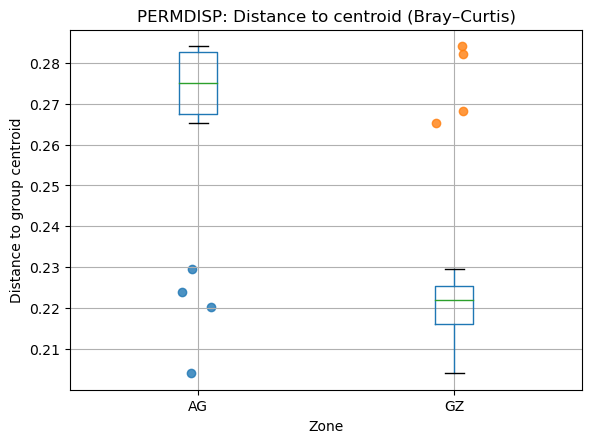

In [9]:
# Prepare plotting dataframe
plot_df = pd.DataFrame({
    "Zone": groups.values,
    "Distance_to_centroid": permdisp_res["distances"]
})

# Boxplot + points
plt.figure()
plot_df.boxplot(column="Distance_to_centroid", by="Zone")

for i, zone in enumerate(plot_df.Zone.unique(), start=1):
    y = plot_df.loc[plot_df.Zone == zone, "Distance_to_centroid"]
    x = i + (np.random.rand(len(y)) - 0.5) * 0.15
    plt.scatter(x, y, alpha=0.8)

plt.title("PERMDISP: Distance to centroid (Bray–Curtis)")
plt.suptitle("")
plt.ylabel("Distance to group centroid")
plt.show()

Richness: Wilcoxon p = 0.0591
Shannon: Wilcoxon p = 0.1143
Simpson: Wilcoxon p = 0.1143
Evenness: Wilcoxon p = 0.2000


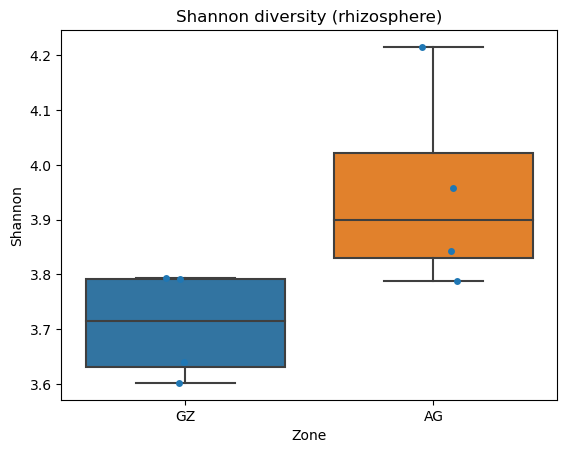

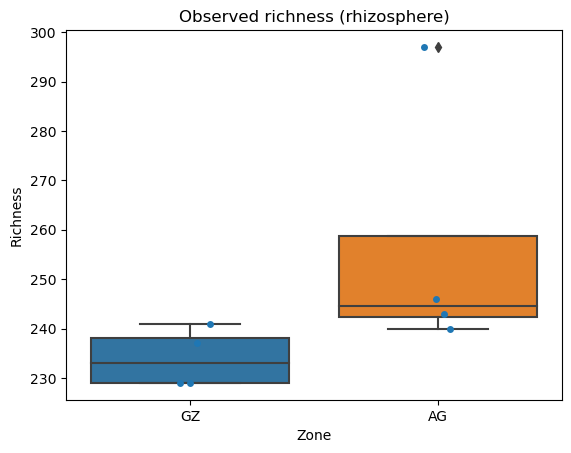

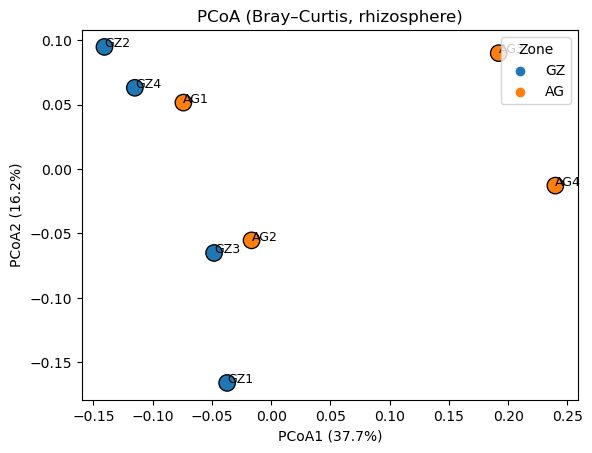


PERMANOVA: {'F': 1.5996219462265169, 'p': 0.119, 'R2': 0.21048704232199159}
PERMDISP : {'F': 31.762045805766498, 'p': 0.028}


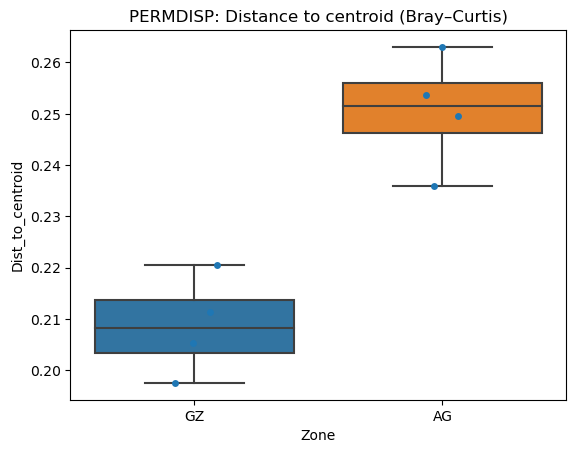


Top differential genera (Wilcoxon + BH-FDR):
           Genus  log2FC_AG_vs_GZ        p      fdr
   Acaryochloris         7.189939 0.453255 0.726575
     Pediococcus         6.594532 0.453255 0.726575
  Pectobacterium        -8.161008 0.453255 0.726575
  Paraprevotella        -7.082716 0.453255 0.726575
   Parachlamydia         6.489310 0.453255 0.726575
         Pantoea         9.060828 0.453255 0.726575
   Pannonibacter         6.489310 0.453255 0.726575
     Oxalobacter         6.594532 0.453255 0.726575
Oxalicibacterium         7.481259 0.453255 0.726575
  Oscillochloris         3.559958 0.026519 0.726575
    Oscillatoria        -1.487765 0.245383 0.726575
           Oryza         6.594532 0.453255 0.726575
       Oerskovia         7.875615 0.185877 0.726575
    Ochrobactrum         8.282741 0.068918 0.726575
 Novosphingobium         1.032101 0.485714 0.726575
          Nostoc         6.489310 0.453255 0.726575
    Nocardiopsis         3.501117 0.054514 0.726575
        Nocardia  

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 0) Load taxonomy table
# ----------------------------
tax_df = pd.read_excel(
    "/Users/kayadetunji/Downloads/soil MB/raw data_taxonomy_CFC.xlsx",
    sheet_name="taxonomy"
)

samples = ["GZ1","GZ2","GZ3","GZ4","AG1","AG2","AG3","AG4"]

# ----------------------------
# 1) Build a clean genus count table (aggregate duplicate genera)
# ----------------------------
tax_df["genus"] = tax_df["genus"].fillna("unclassified")

genus_counts = (
    tax_df[["genus"] + samples]
    .groupby("genus", as_index=True)[samples]
    .sum()
)

# community matrix: samples x genera
counts = genus_counts.T
counts.index.name = "Sample"

meta = pd.DataFrame({"Zone": ["GZ"]*4 + ["AG"]*4}, index=counts.index)

# optional: drop genera with zero total counts
counts = counts.loc[:, counts.sum(axis=0) > 0]

# ----------------------------
# 2) Alpha diversity (per sample)
# ----------------------------
def shannon(x):
    x = np.asarray(x, dtype=float)
    if x.sum() == 0:
        return 0.0
    p = x[x > 0] / x.sum()
    return -(p * np.log(p)).sum()

def simpson_1mD(x):
    x = np.asarray(x, dtype=float)
    if x.sum() == 0:
        return 0.0
    p = x[x > 0] / x.sum()
    return 1.0 - (p**2).sum()

def richness(x):
    x = np.asarray(x, dtype=float)
    return int((x > 0).sum())

def pielou_evenness(x):
    S = richness(x)
    if S <= 1:
        return 0.0
    return shannon(x) / np.log(S)

alpha = pd.DataFrame({
    "Richness": counts.apply(richness, axis=1),
    "Shannon": counts.apply(shannon, axis=1),
    "Simpson": counts.apply(simpson_1mD, axis=1),
    "Evenness": counts.apply(pielou_evenness, axis=1)
}).join(meta)

# Wilcoxon tests
for m in ["Richness","Shannon","Simpson","Evenness"]:
    gz = alpha.loc[alpha.Zone=="GZ", m]
    ag = alpha.loc[alpha.Zone=="AG", m]
    p = mannwhitneyu(gz, ag, alternative="two-sided").pvalue
    print(f"{m}: Wilcoxon p = {p:.4f}")

# Alpha plots
plt.figure()
sns.boxplot(data=alpha, x="Zone", y="Shannon")
sns.stripplot(data=alpha, x="Zone", y="Shannon", dodge=True)
plt.title("Shannon diversity (rhizosphere)")
plt.show()

plt.figure()
sns.boxplot(data=alpha, x="Zone", y="Richness")
sns.stripplot(data=alpha, x="Zone", y="Richness", dodge=True)
plt.title("Observed richness (rhizosphere)")
plt.show()

# ----------------------------
# 3) Beta diversity: Bray–Curtis + TRUE PCoA
# ----------------------------
rel = counts.div(counts.sum(axis=1), axis=0)

D = squareform(pdist(rel.values, metric="braycurtis"))

def pcoa(distance_matrix, n_components=2):
    D = np.asarray(distance_matrix, dtype=float)
    n = D.shape[0]
    D2 = D**2
    J = np.eye(n) - np.ones((n, n))/n
    B = -0.5 * J @ D2 @ J
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    pos = eigvals > 1e-12
    eigvals, eigvecs = eigvals[pos], eigvecs[:, pos]
    coords = eigvecs[:, :n_components] * np.sqrt(eigvals[:n_components])
    var = eigvals / eigvals.sum()
    return coords, var

coords, var = pcoa(D, n_components=2)
ord_df = pd.DataFrame(coords, columns=["PCoA1","PCoA2"], index=rel.index).join(meta)

plt.figure()
sns.scatterplot(data=ord_df, x="PCoA1", y="PCoA2", hue="Zone", s=140, edgecolor="black")
for s, r in ord_df.iterrows():
    plt.text(r.PCoA1, r.PCoA2, s, fontsize=9)
plt.xlabel(f"PCoA1 ({var[0]*100:.1f}%)")
plt.ylabel(f"PCoA2 ({var[1]*100:.1f}%)")
plt.title("PCoA (Bray–Curtis, rhizosphere)")
plt.show()

# ----------------------------
# 4) PERMANOVA (permutation) + PERMDISP (dispersion)
# ----------------------------
def permanova(distance_matrix, grouping, permutations=999, seed=42):
    rng = np.random.default_rng(seed)
    D = np.asarray(distance_matrix, dtype=float)
    n = D.shape[0]
    groups = np.asarray(grouping)

    D2 = D**2
    J = np.eye(n) - np.ones((n,n))/n
    A = -0.5 * J @ D2 @ J
    SST = np.trace(A)

    levels = pd.unique(groups)
    X = np.column_stack([(groups == lev).astype(float) for lev in levels])
    XtX_inv = np.linalg.pinv(X.T @ X)
    H = X @ XtX_inv @ X.T

    SSB = np.trace(H @ A)
    SSW = SST - SSB
    dfb = len(levels) - 1
    dfw = n - len(levels)

    F_obs = (SSB/dfb) / (SSW/dfw)
    R2 = SSB / SST

    perm_F = np.zeros(permutations)
    for i in range(permutations):
        perm = rng.permutation(n)
        Xp = X[perm, :]
        Hp = Xp @ XtX_inv @ Xp.T
        SSBp = np.trace(Hp @ A)
        SSWp = SST - SSBp
        perm_F[i] = (SSBp/dfb) / (SSWp/dfw)

    p = (np.sum(perm_F >= F_obs) + 1) / (permutations + 1)
    return {"F": F_obs, "p": p, "R2": R2}

def permdisp(distance_matrix, grouping, permutations=999, seed=42):
    rng = np.random.default_rng(seed)
    D = np.asarray(distance_matrix, dtype=float)
    groups = np.asarray(grouping)
    levels = pd.unique(groups)
    n = len(groups)

    # distance to centroid = mean within-group distance
    d = np.zeros(n)
    for lev in levels:
        idx = np.where(groups == lev)[0]
        subD = D[np.ix_(idx, idx)]
        d[idx] = subD.mean(axis=1)

    grand = d.mean()
    ssb = sum(len(d[groups==lev]) * (d[groups==lev].mean() - grand)**2 for lev in levels)
    ssw = sum(((d[groups==lev] - d[groups==lev].mean())**2).sum() for lev in levels)
    dfb = len(levels)-1
    dfw = n - len(levels)
    F_obs = (ssb/dfb) / (ssw/dfw)

    perm_F = np.zeros(permutations)
    for i in range(permutations):
        perm_g = rng.permutation(groups)
        ssb_p = sum(len(d[perm_g==lev]) * (d[perm_g==lev].mean() - grand)**2 for lev in levels)
        ssw_p = sum(((d[perm_g==lev] - d[perm_g==lev].mean())**2).sum() for lev in levels)
        perm_F[i] = (ssb_p/dfb) / (ssw_p/dfw)

    p = (np.sum(perm_F >= F_obs) + 1) / (permutations + 1)
    return {"F": F_obs, "p": p, "dist_to_centroid": d}

perm_res = permanova(D, meta["Zone"].values, permutations=999)
disp_res = permdisp(D, meta["Zone"].values, permutations=999)

print("\nPERMANOVA:", perm_res)
print("PERMDISP :", {k:v for k,v in disp_res.items() if k != "dist_to_centroid"})

# PERMDISP boxplot
disp_df = pd.DataFrame({"Zone": meta["Zone"].values, "Dist_to_centroid": disp_res["dist_to_centroid"]},
                       index=meta.index)

plt.figure()
sns.boxplot(data=disp_df, x="Zone", y="Dist_to_centroid")
sns.stripplot(data=disp_df, x="Zone", y="Dist_to_centroid", dodge=True)
plt.title("PERMDISP: Distance to centroid (Bray–Curtis)")
plt.show()

# ----------------------------
# 5) Differential abundance (simple, transparent)
#    per-genus Wilcoxon + BH-FDR + log2FC
# ----------------------------
def bh_fdr(pvals):
    pvals = np.asarray(pvals)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * n / (np.arange(1, n+1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.clip(q, 0, 1)
    return out

# small pseudocount for log2FC on relative abundance
pseudo = 1e-6
rel = rel + pseudo

results = []
for g in rel.columns:
    gz = rel.loc[meta.Zone=="GZ", g]
    ag = rel.loc[meta.Zone=="AG", g]
    p = mannwhitneyu(gz, ag, alternative="two-sided").pvalue
    log2fc = np.log2(ag.mean() / gz.mean())
    results.append((g, log2fc, p))

da = pd.DataFrame(results, columns=["Genus","log2FC_AG_vs_GZ","p"])
da["fdr"] = bh_fdr(da["p"].values)
da = da.sort_values("fdr")

print("\nTop differential genera (Wilcoxon + BH-FDR):")
print(da.head(20).to_string(index=False))